# Main

Pipeline gabungan untuk setup, eksperimen, evaluasi, dan visualisasi.


---

# 00 Setup


# 0. Setup

Setup path, dependency, GPU, dan data.


In [61]:
from pathlib import Path
import os
import sys
import shutil
import subprocess
import zipfile
import json

REPO_NAME = 'ML-Tubes-2_RecursiveLearnaholic'
REPO_URL = 'https://github.com/Rusmn/ML-Tubes-2_RecursiveLearnaholic.git'
BRANCH = None
GPU_REQUIRED = None
USE_SYMLINK = True
DOWNLOAD_DATA = False

KAGGLE_WORK = Path('/kaggle/working')
KAGGLE_INPUT = Path('/kaggle/input')
COLAB_WORK = Path('/content')


def detect_platform():
    if KAGGLE_WORK.exists():
        return 'kaggle', KAGGLE_WORK, KAGGLE_INPUT
    if COLAB_WORK.exists():
        return 'colab', COLAB_WORK, COLAB_WORK
    return 'local', Path.cwd().resolve(), Path.cwd().resolve()


def find_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start] + list(start.parents):
        if (path / 'src').exists() and (path / 'data').exists():
            return path
    return None

PLATFORM, WORK_DIR, INPUT_DIR = detect_platform()
if GPU_REQUIRED is None:
    GPU_REQUIRED = PLATFORM in {'kaggle', 'colab'}
ROOT = find_root()
if ROOT is None and PLATFORM in {'kaggle', 'colab'}:
    ROOT = WORK_DIR / REPO_NAME
    if not (ROOT / 'src').exists():
        cmd = ['git', 'clone', '--depth', '1']
        if BRANCH:
            cmd += ['--branch', BRANCH]
        cmd += [REPO_URL, str(ROOT)]
        subprocess.run(cmd, check=True)
elif ROOT is None:
    raise RuntimeError('root repo tidak ditemukan')

ROOT = ROOT.resolve()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print('platform:', PLATFORM)
print('root:', ROOT)
print('input:', INPUT_DIR)


platform: local
root: /Users/rusmn/Kuliah/SEMESTER 6/Machine Learning/Tubes2/ML-Tubes-2_RecursiveLearnaholic
input: /Users/rusmn/Kuliah/SEMESTER 6/Machine Learning/Tubes2/ML-Tubes-2_RecursiveLearnaholic/notebooks


In [62]:
import importlib

required = ['numpy', 'pandas', 'matplotlib', 'tensorflow', 'sklearn', 'PIL']
missing = []
for package in required:
    try:
        importlib.import_module('PIL' if package == 'PIL' else package)
        print(package, 'ok')
    except Exception as exc:
        print(package, 'missing:', exc)
        missing.append(package)

if missing:
    print('dependency kurang:', missing)


numpy ok
pandas ok
matplotlib ok
tensorflow ok
sklearn ok
PIL ok


In [63]:
try:
    import tensorflow as tf
    gpus = tf.config.list_physical_devices('GPU')
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception:
            pass
    print('gpu:', len(gpus))
    if GPU_REQUIRED and not gpus:
        raise RuntimeError('gpu tidak tersedia')
except ImportError:
    if GPU_REQUIRED:
        raise
    print('tensorflow belum ada')


gpu: 0


## Data Setup

Cek data yang sudah tersedia. Download hanya jalan jika flag diaktifkan.


In [64]:
IMAGE_EXTS = {'.jpg', '.jpeg', '.png'}
INTEL_CLASSES = {'buildings', 'forest', 'glacier', 'mountain', 'sea', 'street'}


def count_images(path):
    path = Path(path)
    if not path.exists():
        return 0
    return sum(1 for item in path.rglob('*') if item.suffix.lower() in IMAGE_EXTS)


def class_dirs(path):
    path = Path(path)
    if not path.exists():
        return set()
    return {item.name for item in path.iterdir() if item.is_dir()}


def find_intel(search_root):
    search_root = Path(search_root)
    if not search_root.exists():
        return None, None
    candidates = []
    for path in search_root.rglob('*'):
        if not path.is_dir() or path.name.lower() not in {'seg_train', 'seg_test'}:
            continue
        nested = path / path.name
        if INTEL_CLASSES.issubset(class_dirs(path)):
            candidates.append((path.name.lower(), path, count_images(path)))
        elif nested.exists() and INTEL_CLASSES.issubset(class_dirs(nested)):
            candidates.append((path.name.lower(), nested, count_images(nested)))
    train = sorted([item for item in candidates if item[0] == 'seg_train'], key=lambda item: -item[2])
    test = sorted([item for item in candidates if item[0] == 'seg_test'], key=lambda item: -item[2])
    return (train[0][1] if train else None), (test[0][1] if test else None)


def find_flickr(search_root):
    search_root = Path(search_root)
    if not search_root.exists():
        return None, None
    image_dirs = []
    captions = []
    for path in search_root.rglob('*'):
        if path.is_file() and path.name.lower() in {'captions.txt', 'flickr8k.token.txt'}:
            captions.append(path)
        elif path.is_dir() and path.name.lower() in {'images', 'flicker8k_dataset', 'flickr8k_dataset'}:
            total = count_images(path)
            if total >= 7000:
                image_dirs.append((path, total))
    image_dirs = sorted(image_dirs, key=lambda item: -item[1])
    captions = sorted(captions, key=lambda path: (path.name.lower() != 'captions.txt', len(str(path))))
    return (image_dirs[0][0] if image_dirs else None), (captions[0] if captions else None)


def extract_zips(search_root, extract_root):
    search_root = Path(search_root)
    extract_root = Path(extract_root)
    extract_root.mkdir(parents=True, exist_ok=True)
    if not search_root.exists():
        return []
    outputs = []
    for zip_path in search_root.rglob('*.zip'):
        name = zip_path.name.lower()
        if not any(key in name for key in ['intel', 'seg', 'flickr', 'flicker', 'caption']):
            continue
        target = extract_root / zip_path.stem
        marker = extract_root / f'{zip_path.stem}.done'
        if not marker.exists():
            target.mkdir(parents=True, exist_ok=True)
            with zipfile.ZipFile(zip_path) as archive:
                archive.extractall(target)
            marker.write_text('done', encoding='utf-8')
        outputs.append(target)
    return outputs


def download_dataset(slug, target_root):
    target_root = Path(target_root)
    target_root.mkdir(parents=True, exist_ok=True)
    target = target_root / slug.replace('/', '__')
    if target.exists():
        return target
    try:
        import kagglehub
        downloaded = Path(kagglehub.dataset_download(slug))
        try:
            os.symlink(downloaded, target, target_is_directory=True)
        except OSError:
            shutil.copytree(downloaded, target)
        return target
    except Exception:
        target.mkdir(parents=True, exist_ok=True)
        subprocess.run(['kaggle', 'datasets', 'download', '-d', slug, '-p', str(target), '--unzip'], check=True)
        return target


def place(src, dst):
    src = Path(src).resolve()
    dst = Path(dst)
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists() or dst.is_symlink():
        return dst
    if USE_SYMLINK:
        try:
            os.symlink(src, dst, target_is_directory=src.is_dir())
            return dst
        except OSError:
            pass
    if src.is_dir():
        shutil.copytree(src, dst)
    else:
        shutil.copy2(src, dst)
    return dst

search_roots = [ROOT / 'data' / 'raw', INPUT_DIR]
extract_root = WORK_DIR / 'datasets_extracted'
for base in list(search_roots):
    search_roots.extend(extract_zips(base, extract_root))

intel_train = intel_test = flickr_images = flickr_captions = None
for base in search_roots:
    intel_train = intel_train or find_intel(base)[0]
    intel_test = intel_test or find_intel(base)[1]
    flickr_images = flickr_images or find_flickr(base)[0]
    flickr_captions = flickr_captions or find_flickr(base)[1]

if DOWNLOAD_DATA and (intel_train is None or intel_test is None):
    data_root = WORK_DIR / 'kaggle_datasets'
    download_dataset('puneet6060/intel-image-classification', data_root)
    intel_train = intel_train or find_intel(data_root)[0]
    intel_test = intel_test or find_intel(data_root)[1]

if DOWNLOAD_DATA and (flickr_images is None or flickr_captions is None):
    data_root = WORK_DIR / 'kaggle_datasets'
    download_dataset('adityajn105/flickr8k', data_root)
    flickr_images = flickr_images or find_flickr(data_root)[0]
    flickr_captions = flickr_captions or find_flickr(data_root)[1]

missing = []
if intel_train is None: missing.append('Intel train')
if intel_test is None: missing.append('Intel test')
if flickr_images is None: missing.append('Flickr images')
if flickr_captions is None: missing.append('Flickr captions')
if missing:
    raise FileNotFoundError(', '.join(missing))

paths = {
    'intel_train': str(place(intel_train, ROOT / 'data/raw/intel/seg_train')),
    'intel_test': str(place(intel_test, ROOT / 'data/raw/intel/seg_test')),
    'flickr_images': str(place(flickr_images, ROOT / 'data/raw/flickr8k/Images')),
    'flickr_captions': str(place(flickr_captions, ROOT / 'data/raw/flickr8k/captions.txt')),
}
status = {
    'platform': PLATFORM,
    'root': str(ROOT),
    'paths': paths,
    'counts': {
        'intel_train': count_images(paths['intel_train']),
        'intel_test': count_images(paths['intel_test']),
        'flickr_images': count_images(paths['flickr_images']),
    },
}
status_path = ROOT / 'reports/tables/setup_status.json'
status_path.parent.mkdir(parents=True, exist_ok=True)
status_path.write_text(json.dumps(status, indent=2), encoding='utf-8')
print(json.dumps(status, indent=2))


{
  "platform": "local",
  "root": "/Users/rusmn/Kuliah/SEMESTER 6/Machine Learning/Tubes2/ML-Tubes-2_RecursiveLearnaholic",
  "paths": {
    "intel_train": "/Users/rusmn/Kuliah/SEMESTER 6/Machine Learning/Tubes2/ML-Tubes-2_RecursiveLearnaholic/data/raw/intel/seg_train",
    "intel_test": "/Users/rusmn/Kuliah/SEMESTER 6/Machine Learning/Tubes2/ML-Tubes-2_RecursiveLearnaholic/data/raw/intel/seg_test",
    "flickr_images": "/Users/rusmn/Kuliah/SEMESTER 6/Machine Learning/Tubes2/ML-Tubes-2_RecursiveLearnaholic/data/raw/flickr8k/Images",
    "flickr_captions": "/Users/rusmn/Kuliah/SEMESTER 6/Machine Learning/Tubes2/ML-Tubes-2_RecursiveLearnaholic/data/raw/flickr8k/captions.txt"
  },
  "counts": {
    "intel_train": 14034,
    "intel_test": 3000,
    "flickr_images": 8091
  }
}


---

# 01 Cnn


# 1. Cnn

Eksperimen CNN Intel, tabel hasil, dan perbandingan Keras dengan scratch.

In [65]:
from pathlib import Path
import sys

def find_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start] + list(start.parents):
        if (path / 'src').exists() and (path / 'data').exists():
            return path
    raise RuntimeError('root repo tidak ditemukan')

ROOT = find_root()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
print('ROOT:', ROOT)


ROOT: /Users/rusmn/Kuliah/SEMESTER 6/Machine Learning/Tubes2/ML-Tubes-2_RecursiveLearnaholic


In [66]:
import itertools
import json
import pickle
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

from cnn.layers import Conv2D, LocallyConnected2D, MaxPooling2D, AveragePooling2D, Flatten, Dense, Sequential

SEED = 42
IMAGE_SIZE = (150, 150)
CNN_BATCH = 32
CNN_EPOCHS = 5
SKIP_CNN_TRAINING = True
RUN_FULL_NON_SHARED = False
NON_SHARED_SAMPLE_PER_CLASS = 1

CNN_MODEL_DIR = ROOT / 'models' / 'cnn'
TABLE_DIR = ROOT / 'reports' / 'tables'
FIG_DIR = ROOT / 'reports' / 'figures'
for folder in [CNN_MODEL_DIR, TABLE_DIR, FIG_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

TRAIN_DIR = ROOT / 'data/raw/intel/seg_train'
TEST_DIR = ROOT / 'data/raw/intel/seg_test'
CLASSES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
CLASS_TO_ID = {name: idx for idx, name in enumerate(CLASSES)}


In [67]:
def load_intel_dataset(root, target_size=(150, 150)):
    images = []
    labels = []
    for class_name in CLASSES:
        class_dir = Path(root) / class_name
        for path in sorted(class_dir.glob('*.jpg')):
            img = Image.open(path).convert('RGB').resize(target_size)
            images.append(np.asarray(img, dtype='float32') / 255.0)
            labels.append(CLASS_TO_ID[class_name])
    return np.asarray(images, dtype='float32'), np.asarray(labels, dtype='int64')

X_train_full, y_train_full = load_intel_dataset(TRAIN_DIR, IMAGE_SIZE)
X_test, y_test = load_intel_dataset(TEST_DIR, IMAGE_SIZE)
if len(X_train_full) == 0 or len(X_test) == 0:
    raise RuntimeError('data intel belum siap')
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=SEED, stratify=y_train_full
)
print('train:', X_train.shape, 'val:', X_val.shape, 'test:', X_test.shape)


train: (11227, 150, 150, 3) val: (2807, 150, 150, 3) test: (3000, 150, 150, 3)


In [68]:
def make_cnn_model(num_layers, filters, kernel_size, pooling):
    pool_layer = layers.MaxPooling2D if pooling == 'max' else layers.AveragePooling2D
    model_layers = [layers.Input(shape=(*IMAGE_SIZE, 3))]
    for index in range(num_layers):
        model_layers.append(layers.Conv2D(filters, kernel_size, padding='same', activation='relu'))
        if index > 0:
            model_layers.append(pool_layer(pool_size=(2, 2)))
    model_layers.extend([layers.Flatten(), layers.Dense(len(CLASSES), activation='softmax')])
    model = models.Sequential(model_layers)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


def normalize_cnn_records(df):
    if df.empty:
        return df
    rename = {
        'experiment_id': 'experiment',
        'pooling_type': 'pooling',
        'keras_weight_path': 'weights_path',
    }
    df = df.rename(columns={old: new for old, new in rename.items() if old in df.columns})
    if 'experiment' not in df.columns and 'index' in df.columns:
        df['experiment'] = df['index'].astype(int) - 1
    for exp_id in range(16):
        mask = df.get('experiment', pd.Series(dtype=int)).astype(int) == exp_id if 'experiment' in df.columns else []
        if len(df) and np.any(mask):
            row_index = df.index[mask][0]
            if 'weights_path' not in df.columns or pd.isna(df.loc[row_index].get('weights_path', np.nan)):
                df.loc[row_index, 'weights_path'] = str(CNN_MODEL_DIR / f'keras_weights_exp_{exp_id}.npy')
            if 'history_path' not in df.columns or pd.isna(df.loc[row_index].get('history_path', np.nan)):
                df.loc[row_index, 'history_path'] = str(CNN_MODEL_DIR / f'history_exp_{exp_id}.pkl')
    return df

configs = []
for num_layers, filters, kernel_size, pooling in itertools.product([2, 3], [32, 64], [3, 5], ['max', 'avg']):
    configs.append({'num_layers': num_layers, 'filters': filters, 'kernel_size': kernel_size, 'pooling': pooling})

record_path = TABLE_DIR / 'cnn_records.csv'
records = []

def load_cnn_weight_file(path):
    raw = np.load(path, allow_pickle=True)
    if raw.ndim == 0 and isinstance(raw.item(), dict):
        weights = []
        for value in raw.item().values():
            weights.extend(value)
        return weights
    return list(raw)

train_ds = val_ds = test_ds = None
if not SKIP_CNN_TRAINING:
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(len(X_train), seed=SEED).batch(CNN_BATCH).prefetch(tf.data.AUTOTUNE)
    val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(CNN_BATCH).prefetch(tf.data.AUTOTUNE)
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(CNN_BATCH).prefetch(tf.data.AUTOTUNE)

for exp_id, cfg in enumerate(configs):
    weight_path = CNN_MODEL_DIR / f'keras_weights_exp_{exp_id}.npy'
    history_path = CNN_MODEL_DIR / f'history_exp_{exp_id}.pkl'
    tf.keras.backend.clear_session()
    model = make_cnn_model(**cfg)
    if weight_path.exists() and history_path.exists():
        print(f'>>> Skipping Experiment {exp_id + 1}/16: Already completed.')
        model.set_weights(load_cnn_weight_file(weight_path))
        elapsed = 0.0
    else:
        if SKIP_CNN_TRAINING:
            raise RuntimeError(f'artefak cnn belum lengkap: exp {exp_id + 1}')
        print(f'>>> Training Experiment {exp_id + 1}/16')
        t0 = time.time()
        history = model.fit(train_ds, validation_data=val_ds, epochs=CNN_EPOCHS, verbose=1)
        elapsed = time.time() - t0
        np.save(weight_path, np.array(model.get_weights(), dtype=object), allow_pickle=True)
        with open(history_path, 'wb') as file:
            pickle.dump(history.history, file)
    preds = np.argmax(model.predict(X_test, batch_size=CNN_BATCH, verbose=0), axis=1)[:len(y_test)]
    f1 = f1_score(y_test, preds, average='macro')
    records.append({
        'experiment': exp_id,
        **cfg,
        'macro_f1': float(f1),
        'runtime_seconds': float(elapsed),
        'weights_path': str(weight_path),
        'history_path': str(history_path),
    })
    pd.DataFrame(records).sort_values('experiment').to_csv(record_path, index=False)

cnn_df = normalize_cnn_records(pd.DataFrame(records)).sort_values('macro_f1', ascending=False)
cnn_df.to_csv(record_path, index=False)
cnn_df.head()


>>> Skipping Experiment 1/16: Already completed.
>>> Skipping Experiment 2/16: Already completed.
>>> Skipping Experiment 3/16: Already completed.
>>> Skipping Experiment 4/16: Already completed.
>>> Skipping Experiment 5/16: Already completed.
>>> Skipping Experiment 6/16: Already completed.
>>> Skipping Experiment 7/16: Already completed.
>>> Skipping Experiment 8/16: Already completed.
>>> Skipping Experiment 9/16: Already completed.
>>> Skipping Experiment 10/16: Already completed.
>>> Skipping Experiment 11/16: Already completed.
>>> Skipping Experiment 12/16: Already completed.
>>> Skipping Experiment 13/16: Already completed.
>>> Skipping Experiment 14/16: Already completed.
>>> Skipping Experiment 15/16: Already completed.
>>> Skipping Experiment 16/16: Already completed.


,experiment,num_layers,filters,kernel_size,pooling,macro_f1,runtime_seconds,weights_path,history_path
12,12,3,64,3,max,0.760607,0.0,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...
8,8,3,32,3,max,0.743906,0.0,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...
14,14,3,64,5,max,0.741806,0.0,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...
1,1,2,32,3,avg,0.737065,0.0,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...
13,13,3,64,3,avg,0.735633,0.0,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...


In [69]:
cnn_df = normalize_cnn_records(pd.read_csv(TABLE_DIR / 'cnn_records.csv'))
best = cnn_df.sort_values('macro_f1', ascending=False).iloc[0]
best_exp = int(best['experiment'])
best_cfg = {
    'num_layers': int(best['num_layers']),
    'filters': int(best['filters']),
    'kernel_size': int(best['kernel_size']),
    'pooling': str(best['pooling']),
}
print('best:', best_exp, best_cfg)

manual_path = TABLE_DIR / 'cnn_manual_comparison.csv'
best_model = make_cnn_model(**best_cfg)
best_weights = load_cnn_weight_file(CNN_MODEL_DIR / f'keras_weights_exp_{best_exp}.npy')
best_model.set_weights(best_weights)

sample_idx = []
per_class = None if RUN_FULL_NON_SHARED else NON_SHARED_SAMPLE_PER_CLASS
for label in sorted(np.unique(y_test)):
    candidates = np.flatnonzero(y_test == label)
    sample_idx.extend(candidates.tolist() if per_class is None else candidates[:per_class].tolist())
X_sample = X_test[sample_idx]
y_sample = y_test[sample_idx]
keras_pred = np.argmax(best_model.predict(X_sample, verbose=0), axis=1)

shared_layers = []
non_shared_layers = []
weight_iter = iter(best_model.get_weights())
h, w, channels = IMAGE_SIZE[0], IMAGE_SIZE[1], 3
non_shared_params = 0
for layer in best_model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        kernel = next(weight_iter); bias = next(weight_iter)
        conv = Conv2D(filters=kernel.shape[-1], kernel_size=kernel.shape[:2], padding=kernel.shape[0] // 2, activation='relu')
        conv.load_keras([kernel, bias])
        shared_layers.append(conv)

        local = LocallyConnected2D(filters=kernel.shape[-1], input_size=(h, w), kernel_size=kernel.shape[:2], padding=kernel.shape[0] // 2, activation='relu')
        local.load_tiled_conv(kernel, bias, output_size=(h, w))
        non_shared_layers.append(local)
        non_shared_params += h * w * ((kernel.shape[0] * kernel.shape[1] * channels * kernel.shape[-1]) + kernel.shape[-1])
        channels = kernel.shape[-1]
    elif isinstance(layer, tf.keras.layers.MaxPooling2D):
        shared_layers.append(MaxPooling2D(pool_size=(2, 2), strides=2))
        non_shared_layers.append(MaxPooling2D(pool_size=(2, 2), strides=2))
        h //= 2; w //= 2
    elif isinstance(layer, tf.keras.layers.AveragePooling2D):
        shared_layers.append(AveragePooling2D(pool_size=(2, 2), strides=2))
        non_shared_layers.append(AveragePooling2D(pool_size=(2, 2), strides=2))
        h //= 2; w //= 2
    elif isinstance(layer, tf.keras.layers.Flatten):
        shared_layers.append(Flatten())
        non_shared_layers.append(Flatten())
    elif isinstance(layer, tf.keras.layers.Dense):
        kernel = next(weight_iter); bias = next(weight_iter)
        dense_shared = Dense(activation='softmax')
        dense_shared.load_keras([kernel, bias])
        shared_layers.append(dense_shared)
        dense_local = Dense(activation='softmax')
        dense_local.load_keras([kernel, bias])
        non_shared_layers.append(dense_local)
        non_shared_params += int(np.prod(kernel.shape) + np.prod(bias.shape))

t0 = time.time()
shared_model = Sequential(shared_layers)
shared_pred = np.argmax(shared_model.forward(X_sample), axis=1)
shared_seconds = time.time() - t0
shared_params = shared_model.count_params()

t0 = time.time()
non_shared_model = Sequential(non_shared_layers)
non_shared_pred = np.argmax(non_shared_model.forward(X_sample), axis=1)
non_shared_seconds = time.time() - t0

manual = pd.DataFrame([
    {'implementation': 'keras_shared', 'macro_f1': f1_score(y_sample, keras_pred, average='macro'), 'runtime_seconds': np.nan, 'params': int(best_model.count_params()), 'numerical_match': True, 'shared_parameters': True, 'sample_size': int(len(y_sample))},
    {'implementation': 'scratch_numpy_shared', 'macro_f1': f1_score(y_sample, shared_pred, average='macro'), 'runtime_seconds': shared_seconds, 'params': int(shared_params), 'numerical_match': bool(np.array_equal(keras_pred, shared_pred)), 'shared_parameters': True, 'sample_size': int(len(y_sample))},
    {'implementation': 'scratch_numpy_non_shared', 'macro_f1': f1_score(y_sample, non_shared_pred, average='macro'), 'runtime_seconds': non_shared_seconds, 'params': int(non_shared_params), 'numerical_match': bool(np.array_equal(keras_pred, non_shared_pred)), 'shared_parameters': False, 'sample_size': int(len(y_sample)), 'parameter_explosion': float(non_shared_params / max(shared_params, 1))},
])
manual.to_csv(manual_path, index=False)
print('scratch cnn dihitung ulang')
manual


best: 12 {'num_layers': 3, 'filters': 64, 'kernel_size': 3, 'pooling': 'max'}
scratch cnn dihitung ulang


,implementation,macro_f1,runtime_seconds,params,numerical_match,shared_parameters,sample_size,parameter_explosion
0,keras_shared,0.777778,NaN,601350,True,True,6,NaN
1,scratch_numpy_shared,0.777778,1.221591,601350,True,True,6,NaN
2,scratch_numpy_non_shared,0.777778,2.869034,1079445702,True,False,6,1795.037336


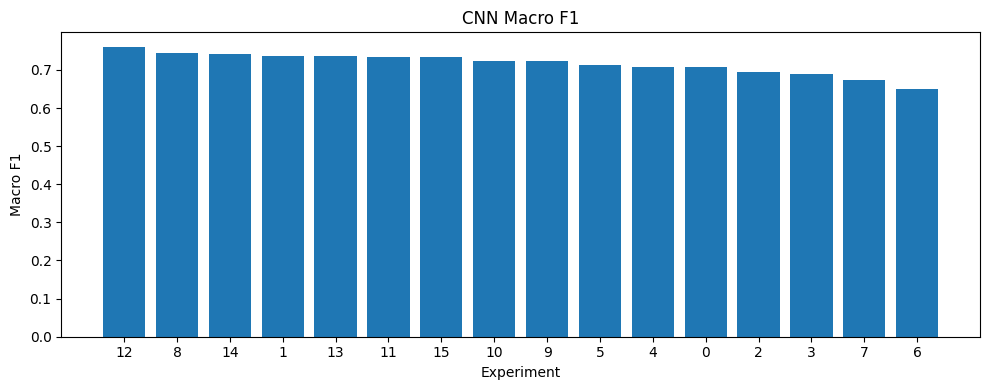

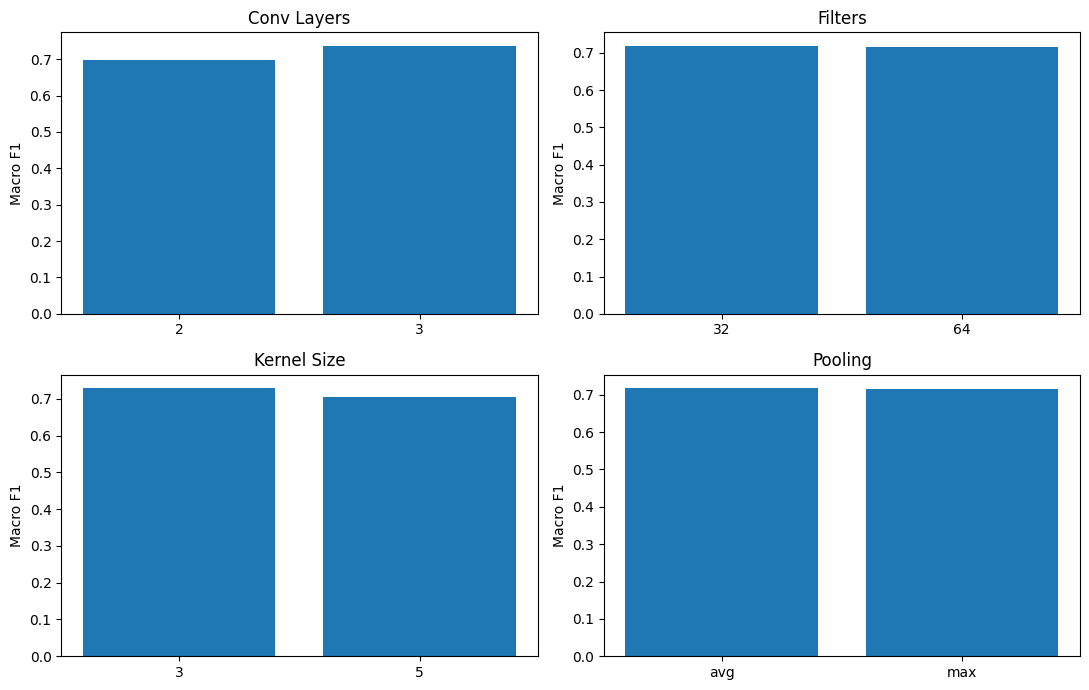

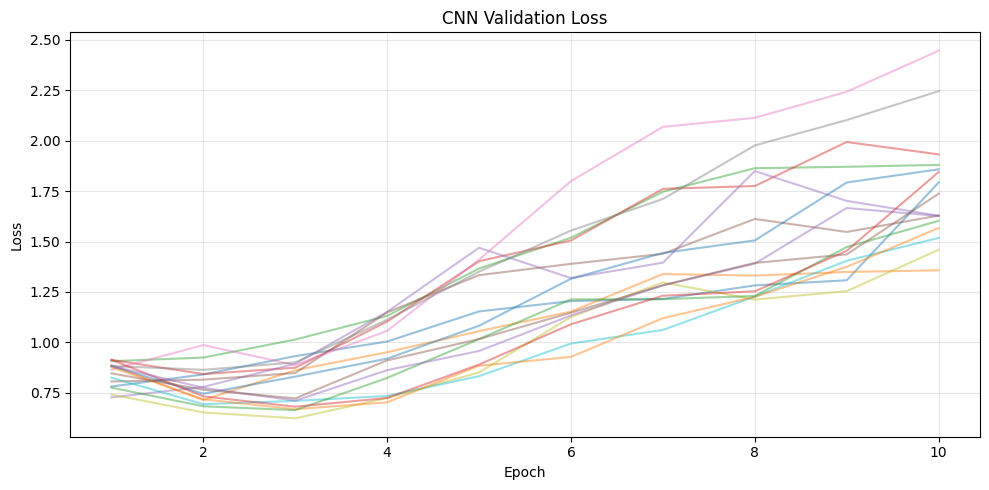

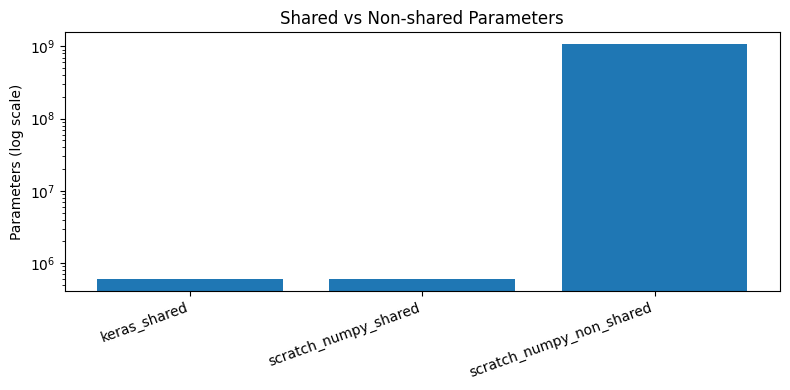

In [70]:
cnn_df = normalize_cnn_records(pd.read_csv(TABLE_DIR / 'cnn_records.csv'))
for group_col, out_name in [
    ('num_layers', 'cnn_by_num_layers.csv'),
    ('filters', 'cnn_by_filters.csv'),
    ('kernel_size', 'cnn_by_kernel_size.csv'),
    ('pooling', 'cnn_by_pooling_type.csv'),
]:
    cnn_df.groupby(group_col)[['macro_f1']].mean().reset_index().to_csv(TABLE_DIR / out_name, index=False)

plt.figure(figsize=(10, 4))
plt.bar(cnn_df['experiment'].astype(str), cnn_df['macro_f1'])
plt.xlabel('Experiment')
plt.ylabel('Macro F1')
plt.title('CNN Macro F1')
plt.tight_layout()
plt.savefig(FIG_DIR / 'cnn_macro_f1.png', dpi=150)
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for axis, (group_col, title) in zip(axes.ravel(), [('num_layers', 'Conv Layers'), ('filters', 'Filters'), ('kernel_size', 'Kernel Size'), ('pooling', 'Pooling')]):
    summary = cnn_df.groupby(group_col)['macro_f1'].mean().reset_index()
    axis.bar(summary[group_col].astype(str), summary['macro_f1'])
    axis.set_title(title)
    axis.set_ylabel('Macro F1')
fig.tight_layout()
fig.savefig(FIG_DIR / 'cnn_hyperparameters.png', dpi=150)
plt.show()

loss_rows = []
for row in cnn_df.itertuples():
    history_path = Path(getattr(row, 'history_path'))
    if not history_path.is_absolute():
        history_path = ROOT / history_path
    if not history_path.exists():
        continue
    with open(history_path, 'rb') as file:
        history = pickle.load(file)
    for epoch, (loss, val_loss) in enumerate(zip(history.get('loss', []), history.get('val_loss', [])), start=1):
        loss_rows.append({'experiment': int(row.experiment), 'epoch': epoch, 'loss': loss, 'val_loss': val_loss})
loss_df = pd.DataFrame(loss_rows)
if not loss_df.empty:
    plt.figure(figsize=(10, 5))
    for exp_id, part in loss_df.groupby('experiment'):
        plt.plot(part['epoch'], part['val_loss'], alpha=0.45, label=str(exp_id))
    plt.title('CNN Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'cnn_validation_loss.png', dpi=150)
    plt.show()

manual = pd.read_csv(TABLE_DIR / 'cnn_manual_comparison.csv')
if {'implementation', 'params'}.issubset(manual.columns):
    plt.figure(figsize=(8, 4))
    plt.bar(manual['implementation'], pd.to_numeric(manual['params'], errors='coerce'))
    plt.yscale('log')
    plt.xticks(rotation=20, ha='right')
    plt.ylabel('Parameters (log scale)')
    plt.title('Shared vs Non-shared Parameters')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'cnn_shared_parameters.png', dpi=150)
    plt.show()


---

# 02 Caption


# 2. Caption

Feature Flickr8k, split image, dan vocabulary caption.

In [71]:
from pathlib import Path
import sys

def find_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start] + list(start.parents):
        if (path / 'src').exists() and (path / 'data').exists():
            return path
    raise RuntimeError('root repo tidak ditemukan')

ROOT = find_root()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
print('ROOT:', ROOT)


ROOT: /Users/rusmn/Kuliah/SEMESTER 6/Machine Learning/Tubes2/ML-Tubes-2_RecursiveLearnaholic


In [72]:
import json
import re
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf

from cnn.utility import image_paths, feature_extractor
from rnn.preprocess import clean_text, tokenize, make_vocab, pad_seq

SEED = 42
MAX_SEQUENCE_LENGTH = 34
MIN_WORD_FREQ = 1
FEATURE_BATCH = 64
IMAGE_SIZE = (299, 299)
TRAIN_RATIO = 0.75
VAL_RATIO = 0.125

RAW_DIR = ROOT / 'data/raw/flickr8k'
IMAGE_DIR = RAW_DIR / 'Images'
CAPTION_PATH = RAW_DIR / 'captions.txt'
FEATURE_DIR = ROOT / 'data/features'
PROC_DIR = ROOT / 'data/processed/flickr8k'
TABLE_DIR = ROOT / 'reports/tables'
for folder in [FEATURE_DIR, PROC_DIR, TABLE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)


In [73]:
def parse_captions(path):
    by_image = defaultdict(list)
    with Path(path).open('r', encoding='utf-8') as file:
        for raw in file:
            line = raw.strip()
            if not line:
                continue
            if ',' in line:
                image_raw, caption = line.split(',', 1)
            elif '	' in line:
                image_raw, caption = line.split('	', 1)
            else:
                continue
            image_id = Path(image_raw.split('#')[0]).name
            if image_id.lower() in {'image', 'filename'}:
                continue
            caption = clean_text(caption)
            if caption:
                by_image[image_id].append(caption)
    return dict(by_image)

caption_by_image = parse_captions(CAPTION_PATH)
print('caption images:', len(caption_by_image))
print('captions:', sum(len(v) for v in caption_by_image.values()))


caption images: 8091
captions: 40455


In [74]:
feature_path = FEATURE_DIR / 'flickr8k_features.npy'
feature_id_path = FEATURE_DIR / 'flickr8k_image_ids.txt'
encoder_path = ROOT / 'models/cnn/flickr8k_inceptionv3_encoder.keras'
encoder_path.parent.mkdir(parents=True, exist_ok=True)

paths = image_paths(IMAGE_DIR)
cached_weights = Path.home() / '.keras/models/inception_v3_weights_tf_dim_ordering_tf_kernels_notop.h5'
weights_arg = str(cached_weights) if cached_weights.exists() else 'imagenet'
encoder = tf.keras.applications.InceptionV3(include_top=False, weights=weights_arg, pooling='avg')
encoder.trainable = False
encoder.save(encoder_path)
features = feature_extractor(
    paths,
    encoder,
    feature_path,
    target_size=IMAGE_SIZE,
    batch_size=FEATURE_BATCH,
    image_id_path=feature_id_path,
    preprocess_fn=tf.keras.applications.inception_v3.preprocess_input,
)
feature_ids = [line.strip() for line in feature_id_path.read_text(encoding='utf-8').splitlines() if line.strip()]
print('fitur tersimpan:', features.shape)

if feature_ids and not feature_ids[0].lower().endswith(('.jpg', '.jpeg', '.png')):
    image_name_lookup = {Path(path).stem: Path(path).name for path in image_paths(IMAGE_DIR)}
    feature_ids = [image_name_lookup.get(image_id, image_id) for image_id in feature_ids]
    feature_id_path.write_text('\n'.join(feature_ids), encoding='utf-8')
    print('id fitur rapi')


fitur tersimpan: (8091, 2048)


In [75]:
feature_ids = [line.strip() for line in feature_id_path.read_text(encoding='utf-8').splitlines() if line.strip()]
features = np.load(feature_path).astype('float32')
valid_ids = sorted(set(feature_ids).intersection(caption_by_image))
split_path = PROC_DIR / 'split.json'

rng = np.random.default_rng(SEED)
order = np.array(valid_ids, dtype=object)
rng.shuffle(order)
n_train = int(round(len(order) * TRAIN_RATIO))
n_val = int(round(len(order) * VAL_RATIO))
split = {
    'train': order[:n_train].tolist(),
    'val': order[n_train:n_train+n_val].tolist(),
    'test': order[n_train+n_val:].tolist(),
}
split_path.write_text(json.dumps(split, indent=2), encoding='utf-8')
print('split:', {key: len(value) for key, value in split.items()})


split: {'train': 6068, 'val': 1011, 'test': 1012}


In [76]:
vocab_path = PROC_DIR / 'vocab.json'
train_captions = [caption for image_id in split['train'] for caption in caption_by_image[image_id]]
word_to_index, _ = make_vocab(train_captions, special=['<pad>', '<start>', '<end>', '<unk>'], min_freq=MIN_WORD_FREQ)
vocab_path.write_text(json.dumps(word_to_index, indent=2), encoding='utf-8')
print('vocab:', len(word_to_index))

feature_lookup = {image_id: features[index] for index, image_id in enumerate(feature_ids)}

def encode_caption(caption):
    pad_id = word_to_index['<pad>']
    ids = [word_to_index['<start>']]
    ids.extend(word_to_index.get(token, word_to_index.get('<unk>', pad_id)) for token in tokenize(caption))
    ids.append(word_to_index['<end>'])
    return pad_seq(ids, MAX_SEQUENCE_LENGTH, pad_id=pad_id)

def build_rows(image_ids):
    row_features = []
    row_sequences = []
    row_ids = []
    missing = []
    for image_id in image_ids:
        if image_id not in feature_lookup or image_id not in caption_by_image:
            missing.append(image_id)
            continue
        for caption in caption_by_image[image_id]:
            row_features.append(feature_lookup[image_id])
            row_sequences.append(encode_caption(caption))
            row_ids.append(image_id)
    if missing:
        print('missing:', len(missing))
    return np.asarray(row_features, dtype='float32'), np.asarray(row_sequences, dtype='int32'), row_ids

for name in ['train', 'val', 'test']:
    row_features, row_sequences, row_ids = build_rows(split[name])
    np.save(PROC_DIR / f'{name}_features.npy', row_features)
    np.save(PROC_DIR / f'{name}_captions.npy', row_sequences)
    (PROC_DIR / f'{name}_image_ids.txt').write_text('\n'.join(row_ids), encoding='utf-8')
    print(name, row_features.shape, row_sequences.shape)

summary = {
    'max_sequence_length': MAX_SEQUENCE_LENGTH,
    'vocab_size': len(word_to_index),
    'split_images': {key: len(value) for key, value in split.items()},
    'source': 'rebuilt',
}
(TABLE_DIR / 'caption_data_summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')
summary


vocab: 7793
train (30340, 2048) (30340, 34)
val (5055, 2048) (5055, 34)
test (5060, 2048) (5060, 34)


{'max_sequence_length': 34,
 'vocab_size': 7793,
 'split_images': {'train': 6068, 'val': 1011, 'test': 1012},
 'source': 'rebuilt'}

---

# 03 Decoder


# 3. Decoder

Decoder RNN/LSTM. Training dilewati jika model sudah ada.


In [77]:
from pathlib import Path
import sys

def find_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start] + list(start.parents):
        if (path / 'src').exists() and (path / 'data').exists():
            return path
    raise RuntimeError('root repo tidak ditemukan')

ROOT = find_root()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
print('ROOT:', ROOT)


ROOT: /Users/rusmn/Kuliah/SEMESTER 6/Machine Learning/Tubes2/ML-Tubes-2_RecursiveLearnaholic


In [78]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf

from rnn.sequences import teacher_pairs
from rnn.keras_models import build_preinject, compile_model
from rnn.train import grid_cfg
from rnn.weights import export_weights

SEED = 42
BATCH_SIZE = 128
EPOCHS = 10
EMBED_DIM = 256
LEARNING_RATE = 1e-3
SKIP_RNN_TRAINING = True

PROC_DIR = ROOT / 'data/processed/flickr8k'
MODEL_DIR = ROOT / 'models/rnn'
TABLE_DIR = ROOT / 'reports/tables/rnn'
for folder in [MODEL_DIR, TABLE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

tf.keras.utils.set_random_seed(SEED)
print('skip train rnn:', SKIP_RNN_TRAINING)


skip train rnn: True


In [79]:
def repo_relative(path):
    path = Path(path)
    try:
        return path.resolve().relative_to(ROOT.resolve()).as_posix()
    except Exception:
        return path.as_posix()

def artifact_path(value):
    path = Path(str(value))
    return path if path.is_absolute() else ROOT / path

def history_dict(history):
    return {key: [float(value) for value in values] for key, values in history.history.items()}

word_to_index = json.loads((PROC_DIR / 'vocab.json').read_text(encoding='utf-8'))
train_features = np.load(PROC_DIR / 'train_features.npy').astype('float32')
train_captions = np.load(PROC_DIR / 'train_captions.npy').astype('int32')
base_config = {
    'vocab_size': len(word_to_index),
    'feature_dim': int(train_features.shape[1]),
    'max_length': int(train_captions.shape[1]),
    'caption_length': int(train_captions.shape[1] - 1),
    'embed_dim': EMBED_DIM,
    'learning_rate': LEARNING_RATE,
    'batch_size': BATCH_SIZE,
    'epochs': EPOCHS,
}
configs = list(grid_cfg(base_config))
print('model rnn:', len(configs))


model rnn: 12


In [80]:
records = []
train_ds = val_ds = None
if not SKIP_RNN_TRAINING:
    val_features = np.load(PROC_DIR / 'val_features.npy').astype('float32')
    val_captions = np.load(PROC_DIR / 'val_captions.npy').astype('int32')

    def make_dataset(features, captions, shuffle=False):
        inputs, targets = teacher_pairs(captions)
        ds = tf.data.Dataset.from_tensor_slices(((features, inputs), targets))
        if shuffle:
            ds = ds.shuffle(min(len(captions), 10000), seed=SEED, reshuffle_each_iteration=True)
        return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    train_ds = make_dataset(train_features, train_captions, shuffle=True)
    val_ds = make_dataset(val_features, val_captions, shuffle=False)

for idx, cfg in enumerate(configs, start=1):
    stem = Path(cfg['model_name']).stem
    model_path = MODEL_DIR / cfg['model_name']
    weight_path = MODEL_DIR / f'{stem}.npz'
    history_path = TABLE_DIR / f'{stem}_history.json'
    record = {
        'config': cfg,
        'model_path': repo_relative(model_path),
        'weight_path': repo_relative(weight_path),
        'history_path': repo_relative(history_path),
    }
    if model_path.exists() and weight_path.exists() and history_path.exists():
        print(f'>>> Skipping Model {idx}/12: Already completed.')
        record['skipped_existing'] = True
        records.append(record)
        continue
    if SKIP_RNN_TRAINING:
        raise RuntimeError(f'artefak rnn belum lengkap: model {idx}')
    print(f'>>> Training Model {idx}/12')
    tf.keras.backend.clear_session()
    model = build_preinject(
        vocab_size=cfg['vocab_size'], feature_dim=cfg['feature_dim'], max_length=cfg['caption_length'],
        embed_dim=cfg['embed_dim'], hidden_size=cfg['hidden_size'], recur_layers=cfg['recur_layers'], recur_type=cfg['recur_type']
    )
    model = compile_model(model, learn_rate=cfg['learning_rate'])
    history = model.fit(train_ds, validation_data=val_ds, epochs=cfg['epochs'], verbose=1)
    model.save(model_path)
    export_weights(model, weight_path)
    history_path.write_text(json.dumps(history_dict(history), indent=2), encoding='utf-8')
    record['skipped_existing'] = False
    records.append(record)
    (TABLE_DIR / 'train_records.json').write_text(json.dumps(records, indent=2), encoding='utf-8')

(TABLE_DIR / 'train_records.json').write_text(json.dumps(records, indent=2), encoding='utf-8')
pd.DataFrame(records)


>>> Skipping Model 1/12: Already completed.
>>> Skipping Model 2/12: Already completed.
>>> Skipping Model 3/12: Already completed.
>>> Skipping Model 4/12: Already completed.
>>> Skipping Model 5/12: Already completed.
>>> Skipping Model 6/12: Already completed.
>>> Skipping Model 7/12: Already completed.
>>> Skipping Model 8/12: Already completed.
>>> Skipping Model 9/12: Already completed.
>>> Skipping Model 10/12: Already completed.
>>> Skipping Model 11/12: Already completed.
>>> Skipping Model 12/12: Already completed.


,config,model_path,weight_path,history_path,skipped_existing
0,"{'vocab_size': 7793, 'feature_dim': 2048, 'max...",models/rnn/rnn_layers1_hidden128_len33.keras,models/rnn/rnn_layers1_hidden128_len33.npz,reports/tables/rnn/rnn_layers1_hidden128_len33...,True
1,"{'vocab_size': 7793, 'feature_dim': 2048, 'max...",models/rnn/rnn_layers1_hidden512_len33.keras,models/rnn/rnn_layers1_hidden512_len33.npz,reports/tables/rnn/rnn_layers1_hidden512_len33...,True
2,"{'vocab_size': 7793, 'feature_dim': 2048, 'max...",models/rnn/rnn_layers2_hidden128_len33.keras,models/rnn/rnn_layers2_hidden128_len33.npz,reports/tables/rnn/rnn_layers2_hidden128_len33...,True
3,"{'vocab_size': 7793, 'feature_dim': 2048, 'max...",models/rnn/rnn_layers2_hidden512_len33.keras,models/rnn/rnn_layers2_hidden512_len33.npz,reports/tables/rnn/rnn_layers2_hidden512_len33...,True
4,"{'vocab_size': 7793, 'feature_dim': 2048, 'max...",models/rnn/rnn_layers3_hidden128_len33.keras,models/rnn/rnn_layers3_hidden128_len33.npz,reports/tables/rnn/rnn_layers3_hidden128_len33...,True
5,"{'vocab_size': 7793, 'feature_dim': 2048, 'max...",models/rnn/rnn_layers3_hidden512_len33.keras,models/rnn/rnn_layers3_hidden512_len33.npz,reports/tables/rnn/rnn_layers3_hidden512_len33...,True
6,"{'vocab_size': 7793, 'feature_dim': 2048, 'max...",models/rnn/lstm_layers1_hidden128_len33.keras,models/rnn/lstm_layers1_hidden128_len33.npz,reports/tables/rnn/lstm_layers1_hidden128_len3...,True
7,"{'vocab_size': 7793, 'feature_dim': 2048, 'max...",models/rnn/lstm_layers1_hidden512_len33.keras,models/rnn/lstm_layers1_hidden512_len33.npz,reports/tables/rnn/lstm_layers1_hidden512_len3...,True
8,"{'vocab_size': 7793, 'feature_dim': 2048, 'max...",models/rnn/lstm_layers2_hidden128_len33.keras,models/rnn/lstm_layers2_hidden128_len33.npz,reports/tables/rnn/lstm_layers2_hidden128_len3...,True
9,"{'vocab_size': 7793, 'feature_dim': 2048, 'max...",models/rnn/lstm_layers2_hidden512_len33.keras,models/rnn/lstm_layers2_hidden512_len33.npz,reports/tables/rnn/lstm_layers2_hidden512_len3...,True


---

# 04 Report


# 4. Report

Tabel, grafik, evaluasi, dan contoh caption untuk laporan.


In [81]:
from pathlib import Path
import sys

def find_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start] + list(start.parents):
        if (path / 'src').exists() and (path / 'data').exists():
            return path
    raise RuntimeError('root repo tidak ditemukan')

ROOT = find_root()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
print('ROOT:', ROOT)


ROOT: /Users/rusmn/Kuliah/SEMESTER 6/Machine Learning/Tubes2/ML-Tubes-2_RecursiveLearnaholic


In [82]:
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from cnn.utility import image_loader
from common.metrics import score_set, bleu4_score
from rnn.caption_decoder import build_decoder

PROC_DIR = ROOT / 'data/processed/flickr8k'
RAW_IMAGE_DIR = ROOT / 'data/raw/flickr8k/Images'
MODEL_DIR = ROOT / 'models/rnn'
TABLE_DIR = ROOT / 'reports/tables/rnn'
FIG_DIR = ROOT / 'reports/figures/rnn'
for folder in [TABLE_DIR, FIG_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

KERAS_BATCH = 128
SCRATCH_BATCH = 32
RAW_DEMO_COUNT = 5

print('report: hitung ulang')


report: hitung ulang


In [83]:
def artifact_path(value):
    path = Path(str(value))
    return path if path.is_absolute() else ROOT / path

def repo_relative(value):
    path = artifact_path(value)
    try:
        return path.resolve().relative_to(ROOT.resolve()).as_posix()
    except Exception:
        return str(value)

def load_json(path, default=None):
    path = Path(path)
    if path.exists():
        return json.loads(path.read_text(encoding='utf-8'))
    return default

def save_json(value, path):
    Path(path).write_text(json.dumps(value, indent=2), encoding='utf-8')

def load_records():
    records = load_json(TABLE_DIR / 'train_records.json', [])
    for record in records:
        record['model_path'] = repo_relative(record['model_path'])
        record['weight_path'] = repo_relative(record['weight_path'])
        record['history_path'] = repo_relative(record['history_path'])
    return records

word_to_index = json.loads((PROC_DIR / 'vocab.json').read_text(encoding='utf-8'))
index_to_word = {int(value): key for key, value in word_to_index.items()}
train_records = load_records()
print('record:', len(train_records))


record: 12


In [84]:
test_features_all = np.load(PROC_DIR / 'test_features.npy').astype('float32')
test_captions_all = np.load(PROC_DIR / 'test_captions.npy').astype('int32')
test_ids_all = [line.strip() for line in (PROC_DIR / 'test_image_ids.txt').read_text(encoding='utf-8').splitlines() if line.strip()]

def seq_words(seq):
    words = []
    for token in np.asarray(seq).astype(int).tolist():
        word = index_to_word.get(token, '<unk>')
        if word in {'<start>', '<pad>'}:
            continue
        if word == '<end>':
            break
        words.append(word)
    return words

# Satu baris evaluasi per image; semua caption referensi image tersebut digabung.
group = {}
for feature, seq, image_id in zip(test_features_all, test_captions_all, test_ids_all):
    if image_id not in group:
        group[image_id] = {'feature': feature, 'refs': []}
    group[image_id]['refs'].append(seq_words(seq))
image_ids = sorted(group)
eval_features = np.asarray([group[image_id]['feature'] for image_id in image_ids], dtype='float32')
eval_refs = [group[image_id]['refs'] for image_id in image_ids]
print('test:', len(image_ids))


test: 1012


In [85]:
def decode_keras(model, features, max_length, batch_size=128):
    pad = word_to_index['<pad>']; start = word_to_index['<start>']; end = word_to_index['<end>']
    outputs = []
    for left in range(0, len(features), batch_size):
        batch = features[left:left+batch_size]
        n = len(batch)
        seq = np.full((n, max_length), pad, dtype='int32')
        gen = np.full((n, max_length), pad, dtype='int32')
        seq[:, 0] = start
        done = np.zeros(n, dtype=bool)
        for step in range(max_length):
            probs = model([batch, seq], training=False).numpy()
            next_ids = np.argmax(probs[:, step, :], axis=-1).astype('int32')
            next_ids[done] = pad
            gen[:, step] = next_ids
            done |= next_ids == end
            if step + 1 < max_length:
                seq[:, step + 1] = next_ids
            if done.all():
                break
        outputs.extend(seq_words(row) for row in gen)
    return outputs

def decode_scratch(decoder, features, max_length, batch_size=32):
    pad = word_to_index['<pad>']; start = word_to_index['<start>']; end = word_to_index['<end>']
    outputs = []
    for left in range(0, len(features), batch_size):
        batch = features[left:left+batch_size]
        n = len(batch)
        seq = np.full((n, max_length), pad, dtype='int32')
        gen = np.full((n, max_length), pad, dtype='int32')
        seq[:, 0] = start
        done = np.zeros(n, dtype=bool)
        for step in range(max_length):
            probs = decoder.predict(batch, seq)
            next_ids = np.argmax(probs[:, step, :], axis=-1).astype('int32')
            next_ids[done] = pad
            gen[:, step] = next_ids
            done |= next_ids == end
            if step + 1 < max_length:
                seq[:, step + 1] = next_ids
            if done.all():
                break
        outputs.extend(seq_words(row) for row in gen)
    return outputs

def score_predictions(predictions, elapsed):
    score = score_set(eval_refs, predictions)
    score['runtime_seconds'] = float(elapsed)
    score['samples'] = len(predictions)
    return score


In [86]:
score_path = TABLE_DIR / 'rnn_lstm_results.json'
scores = []
for record in train_records:
    cfg = record['config']
    model_path = repo_relative(record['model_path'])
    print('evaluasi:', Path(model_path).name)
    model = tf.keras.models.load_model(artifact_path(model_path), safe_mode=False)
    t0 = time.time()
    preds = decode_keras(model, eval_features, int(cfg['caption_length']), KERAS_BATCH)
    elapsed = time.time() - t0
    row = {
        **score_predictions(preds, elapsed),
        'implementation': 'keras',
        'recur_type': cfg['recur_type'],
        'recur_layers': int(cfg['recur_layers']),
        'hidden_size': int(cfg['hidden_size']),
        'model_path': model_path,
        'weight_path': repo_relative(record['weight_path']),
    }
    scores.append(row)
    save_json(scores, score_path)
    pd.DataFrame(scores).to_csv(TABLE_DIR / 'rnn_lstm_results.csv', index=False)

keras_df = pd.DataFrame(scores)
keras_df.to_csv(TABLE_DIR / 'rnn_lstm_results.csv', index=False)
keras_df.sort_values('bleu4', ascending=False).head()


evaluasi: rnn_layers1_hidden128_len33.keras
evaluasi: rnn_layers1_hidden512_len33.keras
evaluasi: rnn_layers2_hidden128_len33.keras
evaluasi: rnn_layers2_hidden512_len33.keras
evaluasi: rnn_layers3_hidden128_len33.keras
evaluasi: rnn_layers3_hidden512_len33.keras
evaluasi: lstm_layers1_hidden128_len33.keras
evaluasi: lstm_layers1_hidden512_len33.keras
evaluasi: lstm_layers2_hidden128_len33.keras
evaluasi: lstm_layers2_hidden512_len33.keras
evaluasi: lstm_layers3_hidden128_len33.keras
evaluasi: lstm_layers3_hidden512_len33.keras


,bleu4,meteor,runtime_seconds,samples,implementation,recur_type,recur_layers,hidden_size,model_path,weight_path
7,0.143036,0.271033,86.196101,1012,keras,lstm,1,512,models/rnn/lstm_layers1_hidden512_len33.keras,models/rnn/lstm_layers1_hidden512_len33.npz
1,0.139430,0.251411,65.503651,1012,keras,rnn,1,512,models/rnn/rnn_layers1_hidden512_len33.keras,models/rnn/rnn_layers1_hidden512_len33.npz
3,0.127190,0.245669,87.610404,1012,keras,rnn,2,512,models/rnn/rnn_layers2_hidden512_len33.keras,models/rnn/rnn_layers2_hidden512_len33.npz
9,0.125369,0.259829,130.869646,1012,keras,lstm,2,512,models/rnn/lstm_layers2_hidden512_len33.keras,models/rnn/lstm_layers2_hidden512_len33.npz
5,0.121609,0.241326,81.858635,1012,keras,rnn,3,512,models/rnn/rnn_layers3_hidden512_len33.keras,models/rnn/rnn_layers3_hidden512_len33.npz


In [87]:
best_by_type = {}
for kind in ['rnn', 'lstm']:
    part = keras_df[keras_df['recur_type'] == kind]
    if len(part):
        best_by_type[kind] = part.sort_values(['bleu4', 'meteor'], ascending=False).iloc[0].to_dict()
print({k: Path(v['model_path']).name for k, v in best_by_type.items()})

scratch_path = TABLE_DIR / 'scratch_best_results.json'
scratch_scores = []
for kind, best in best_by_type.items():
    cfg = {
        'vocab_size': len(word_to_index),
        'feature_dim': int(eval_features.shape[1]),
        'embed_dim': 256,
        'hidden_size': int(best['hidden_size']),
        'recur_layers': int(best['recur_layers']),
        'recur_type': kind,
    }
    print('scratch:', kind)
    decoder = build_decoder(cfg, artifact_path(best['weight_path']))
    t0 = time.time()
    preds = decode_scratch(decoder, eval_features, int(test_captions_all.shape[1] - 1), SCRATCH_BATCH)
    elapsed = time.time() - t0
    row = {
        **score_predictions(preds, elapsed),
        'implementation': 'scratch',
        'recur_type': kind,
        'recur_layers': int(best['recur_layers']),
        'hidden_size': int(best['hidden_size']),
        'model_path': repo_relative(best['model_path']),
        'weight_path': repo_relative(best['weight_path']),
    }
    scratch_scores.append(row)
    save_json(scratch_scores, scratch_path)
    pd.DataFrame(scratch_scores).to_csv(TABLE_DIR / 'scratch_best_results.csv', index=False)

scratch_df = pd.DataFrame(scratch_scores)
scratch_df.to_csv(TABLE_DIR / 'scratch_best_results.csv', index=False)
comparison = pd.concat([pd.DataFrame(best_by_type.values()), scratch_df], ignore_index=True)
comparison.to_csv(TABLE_DIR / 'keras_vs_scratch.csv', index=False)
comparison


{'rnn': 'rnn_layers1_hidden512_len33.keras', 'lstm': 'lstm_layers1_hidden512_len33.keras'}
scratch: rnn
scratch: lstm


,bleu4,meteor,runtime_seconds,samples,implementation,recur_type,recur_layers,hidden_size,model_path,weight_path
0,0.139430,0.251411,65.503651,1012,keras,rnn,1,512,models/rnn/rnn_layers1_hidden512_len33.keras,models/rnn/rnn_layers1_hidden512_len33.npz
1,0.143036,0.271033,86.196101,1012,keras,lstm,1,512,models/rnn/lstm_layers1_hidden512_len33.keras,models/rnn/lstm_layers1_hidden512_len33.npz
2,0.139430,0.251411,61.020888,1012,scratch,rnn,1,512,models/rnn/rnn_layers1_hidden512_len33.keras,models/rnn/rnn_layers1_hidden512_len33.npz
3,0.143036,0.271033,114.729571,1012,scratch,lstm,1,512,models/rnn/lstm_layers1_hidden512_len33.keras,models/rnn/lstm_layers1_hidden512_len33.npz


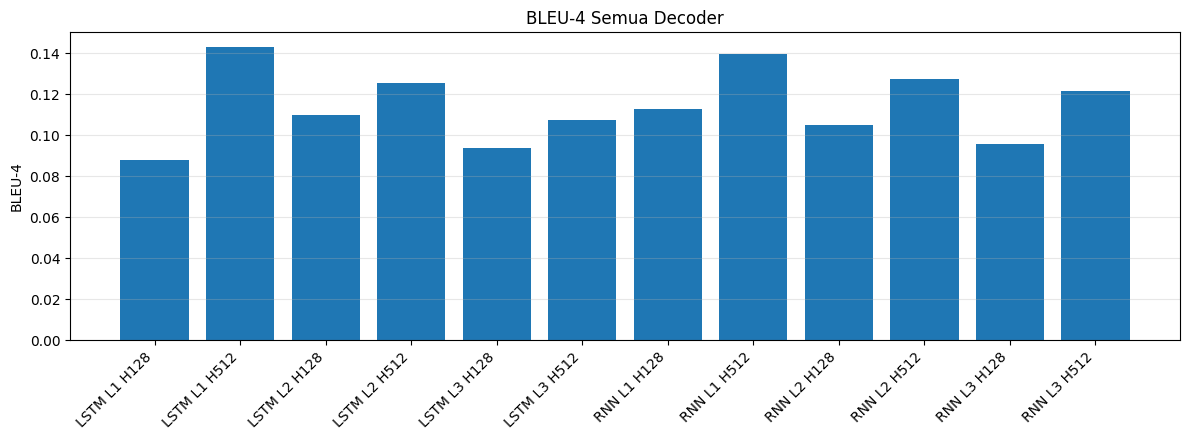

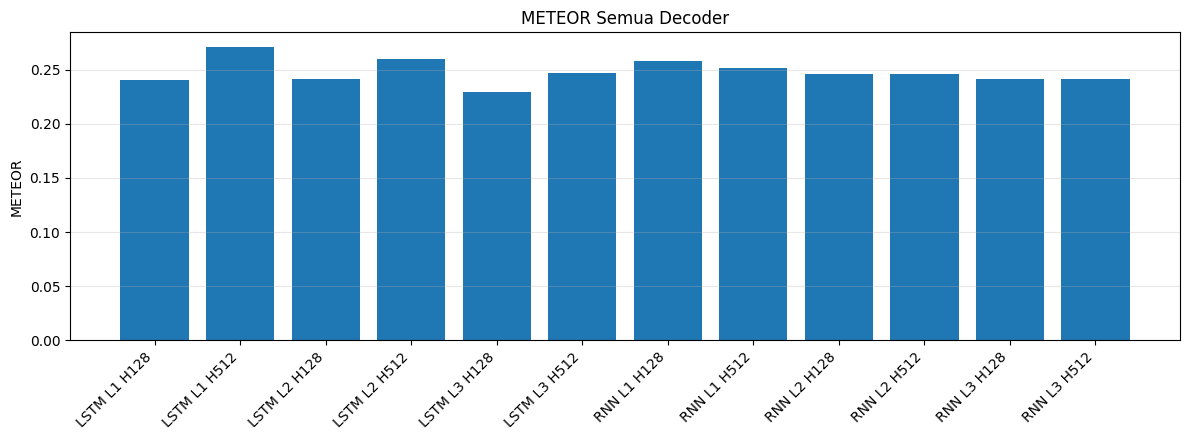

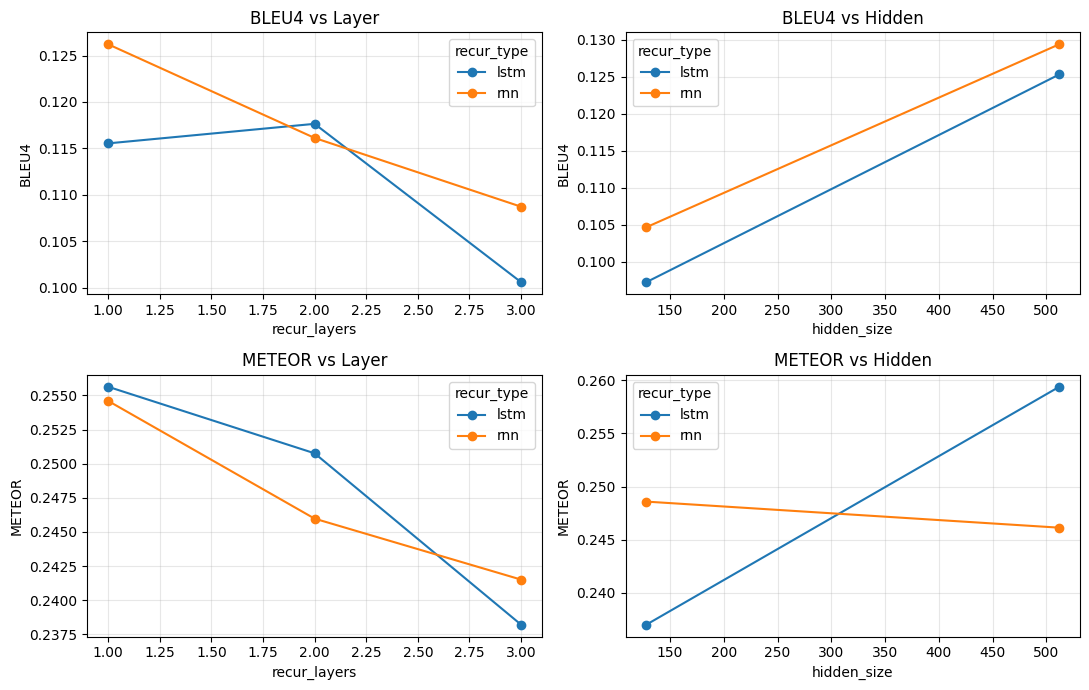

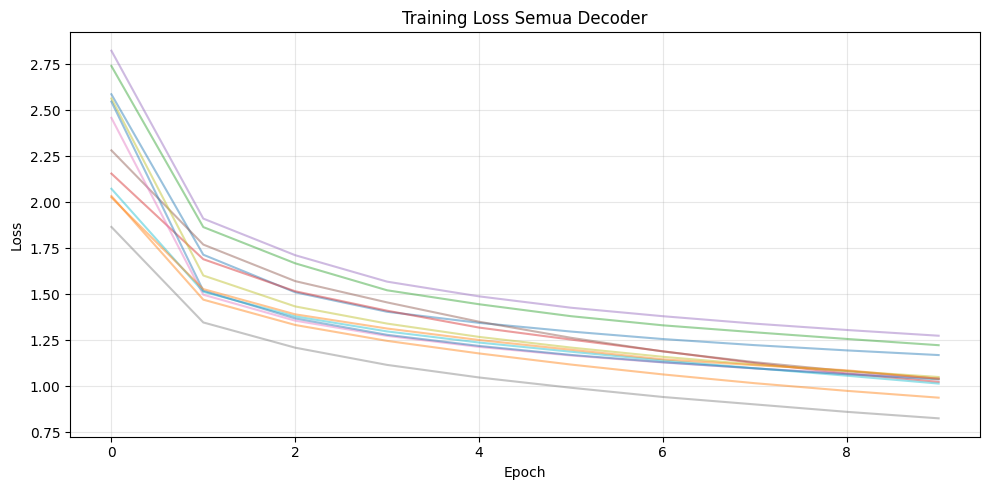

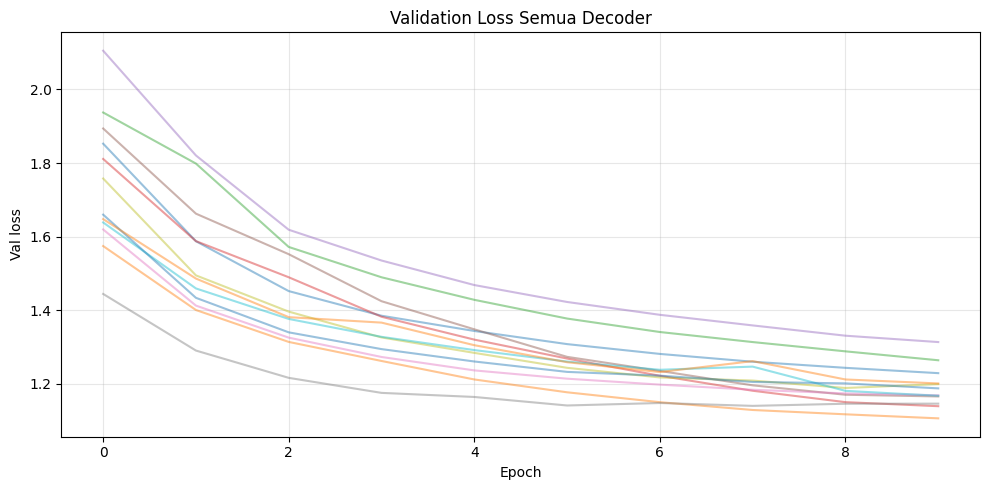

In [88]:
keras_df.groupby(['recur_type', 'recur_layers'])[['bleu4', 'meteor', 'runtime_seconds']].mean().reset_index().to_csv(TABLE_DIR / 'caption_by_recurrent_layers.csv', index=False)
keras_df.groupby(['recur_type', 'hidden_size'])[['bleu4', 'meteor', 'runtime_seconds']].mean().reset_index().to_csv(TABLE_DIR / 'caption_by_hidden_size.csv', index=False)
keras_df.groupby('recur_type')[['bleu4', 'meteor', 'runtime_seconds']].mean().reset_index().to_csv(TABLE_DIR / 'rnn_vs_lstm.csv', index=False)
keras_df.to_csv(TABLE_DIR / 'caption_all_keras_variations.csv', index=False)

plot_scores = keras_df.copy().sort_values(['recur_type', 'recur_layers', 'hidden_size'])
plot_scores['label'] = plot_scores.apply(lambda row: f"{row['recur_type'].upper()} L{int(row['recur_layers'])} H{int(row['hidden_size'])}", axis=1)

plt.figure(figsize=(12, 4.5))
plt.bar(plot_scores['label'], plot_scores['bleu4'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('BLEU-4')
plt.title('BLEU-4 Semua Decoder')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'decoder_bleu4.png', dpi=150)
plt.savefig(FIG_DIR / 'rnn_lstm_bleu4_variations.png', dpi=150)
plt.show()

plt.figure(figsize=(12, 4.5))
plt.bar(plot_scores['label'], plot_scores['meteor'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('METEOR')
plt.title('METEOR Semua Decoder')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'decoder_meteor.png', dpi=150)
plt.savefig(FIG_DIR / 'rnn_lstm_meteor_variations.png', dpi=150)
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for metric, row_axes in [('bleu4', axes[0]), ('meteor', axes[1])]:
    keras_df.groupby(['recur_type', 'recur_layers'])[metric].mean().unstack(0).plot(marker='o', ax=row_axes[0])
    row_axes[0].set_title(f'{metric.upper()} vs Layer')
    row_axes[0].set_ylabel(metric.upper())
    row_axes[0].grid(alpha=0.3)
    keras_df.groupby(['recur_type', 'hidden_size'])[metric].mean().unstack(0).plot(marker='o', ax=row_axes[1])
    row_axes[1].set_title(f'{metric.upper()} vs Hidden')
    row_axes[1].set_ylabel(metric.upper())
    row_axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'rnn_layer_hidden_effects.png', dpi=150)
plt.show()

plt.figure(figsize=(10, 5))
for hist_path in sorted(TABLE_DIR.glob('*_history.json')):
    history = json.loads(hist_path.read_text(encoding='utf-8'))
    label = hist_path.stem.replace('_history', '')
    values = history.get('loss', [])
    if values:
        plt.plot(values, alpha=0.45, label=label)
plt.title('Training Loss Semua Decoder')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'training_loss.png', dpi=150)
plt.savefig(FIG_DIR / 'training_loss_curves.png', dpi=150)
plt.show()

plt.figure(figsize=(10, 5))
for hist_path in sorted(TABLE_DIR.glob('*_history.json')):
    history = json.loads(hist_path.read_text(encoding='utf-8'))
    label = hist_path.stem.replace('_history', '')
    values = history.get('val_loss', [])
    if values:
        plt.plot(values, alpha=0.45, label=label)
plt.title('Validation Loss Semua Decoder')
plt.xlabel('Epoch')
plt.ylabel('Val loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'validation_loss.png', dpi=150)
plt.savefig(FIG_DIR / 'validation_loss_curves.png', dpi=150)
plt.show()


best: keras lstm
length: 10
length: 20
length: 33


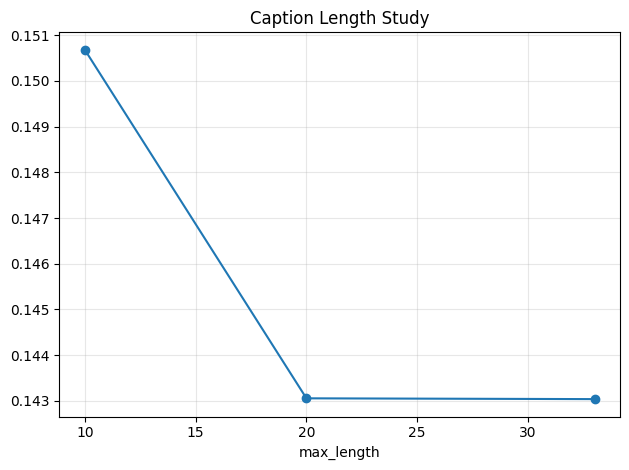

,bleu4,meteor,runtime_seconds,samples,max_length,implementation,recur_type
0,0.150682,0.259596,17.774833,1012,10,keras,lstm
1,0.143053,0.271033,48.349453,1012,20,keras,lstm
2,0.143036,0.271033,93.923327,1012,33,keras,lstm


In [89]:
length_path = TABLE_DIR / 'length_scores.json'
length_scores = []
all_candidates = list(best_by_type.values()) + scratch_scores
best_overall = sorted(all_candidates, key=lambda row: (row.get('bleu4', 0), row.get('meteor', 0)), reverse=True)[0]
print('best:', best_overall['implementation'], best_overall['recur_type'])
for length in [10, 20, int(test_captions_all.shape[1] - 1)]:
    print('length:', length)
    t0 = time.time()
    if best_overall['implementation'] == 'scratch':
        cfg = {
            'vocab_size': len(word_to_index), 'feature_dim': int(eval_features.shape[1]), 'embed_dim': 256,
            'hidden_size': int(best_overall['hidden_size']), 'recur_layers': int(best_overall['recur_layers']), 'recur_type': best_overall['recur_type']
        }
        decoder = build_decoder(cfg, artifact_path(best_overall['weight_path']))
        preds = decode_scratch(decoder, eval_features, length, SCRATCH_BATCH)
    else:
        model = tf.keras.models.load_model(artifact_path(best_overall['model_path']), safe_mode=False)
        preds = decode_keras(model, eval_features, length, KERAS_BATCH)
    elapsed = time.time() - t0
    row = {**score_predictions(preds, elapsed), 'max_length': int(length), 'implementation': best_overall['implementation'], 'recur_type': best_overall['recur_type']}
    length_scores.append(row)
    save_json(length_scores, length_path)

length_df = pd.DataFrame(length_scores)
length_df.to_csv(TABLE_DIR / 'length_scores.csv', index=False)
length_df.plot(x='max_length', y='bleu4', marker='o', legend=False, title='Caption Length Study')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'length_bleu4.png', dpi=150)
plt.show()
length_df


In [90]:
qual_path = TABLE_DIR / 'qualitative_examples.json'
sample_count = len(eval_features)
sample_features = eval_features[:sample_count]
sample_refs = eval_refs[:sample_count]
sample_ids = image_ids[:sample_count]
preds_by_kind = {}
for kind, best in best_by_type.items():
    print('qual:', kind)
    model = tf.keras.models.load_model(artifact_path(best['model_path']), safe_mode=False)
    preds_by_kind[kind] = decode_keras(model, sample_features, int(test_captions_all.shape[1] - 1), KERAS_BATCH)
avg_bleu = []
for idx in range(sample_count):
    vals = [bleu4_score(sample_refs[idx], preds[idx]) for preds in preds_by_kind.values()]
    avg_bleu.append(float(np.mean(vals)))
order = np.argsort(avg_bleu)
selected = []
for pool in np.array_split(order, 3):
    selected.extend(pool[:4].tolist())
selected = selected[:10]
qualitative = []
for idx in selected:
    qualitative.append({
        'image_id': sample_ids[idx],
        'avg_bleu4': avg_bleu[idx],
        'ground_truth': [' '.join(ref) for ref in sample_refs[idx]],
        'rnn_prediction': ' '.join(preds_by_kind.get('rnn', [[]])[idx]) if 'rnn' in preds_by_kind else '',
        'lstm_prediction': ' '.join(preds_by_kind.get('lstm', [[]])[idx]) if 'lstm' in preds_by_kind else '',
    })
save_json(qualitative, qual_path)
pd.DataFrame(qualitative).to_csv(TABLE_DIR / 'qualitative_examples.csv', index=False)
pd.DataFrame(qualitative)


qual: rnn
qual: lstm


,image_id,avg_bleu4,ground_truth,rnn_prediction,lstm_prediction
0,3042380610_c5ea61eef8.jpg,0.015249,[a group of people are standing around a sound...,a man in a black shirt and a woman in a black ...,a man and a woman are sitting on a bench with ...
1,1235580648_7eebaed9bc.jpg,0.016235,"[the <unk> males pose for a picture, the two m...",a man in a black shirt and a woman in a black ...,a man in a blue shirt and a white shirt with a...
2,799431781_65dc312afc.jpg,0.017493,[the little boy covering his mouth is sitting ...,a young girl in a blue shirt is standing in fr...,a woman in a white shirt is holding a baby in ...
3,440184957_267f3f3a2b.jpg,0.017540,"[a clown <unk> cutout pictures of children, a ...",a girl in a blue shirt is standing in front of...,a woman in a white dress is standing in front ...
4,2098174172_e57d86ea03.jpg,0.064565,[a hiker is posing in front of snowy mountains...,a man is standing on a hill by a lake,a man in a red jacket is standing on a snowy m...
5,3310067561_b92017acab.jpg,0.065101,"[a brown dog is sitting on a cobbled pavement,...",a dog chews on a bone,a dog is running through a field of a man in a...
6,3187395715_f2940c2b72.jpg,0.065238,[a boy on skateboard is making a jump from a b...,a girl is jumping on a trampoline,a young boy wearing a blue shirt is jumping of...
7,2379150102_157d718d1d.jpg,0.065254,[a dog <unk> on the side of a fountain another...,a small dog is running on a grassy field,a dog is running through a field of a fence
8,327415627_6313d32a64.jpg,0.136444,[two dogs run along the green grass near the w...,two dogs are running through a field,a dog runs through the grass
9,2325258180_6217dd17eb.jpg,0.136488,[a black and brown dog is laying with a tiger ...,a black dog is running on a grassy field,a black and white dog is running through a gra...


In [91]:
raw_demo_path = TABLE_DIR / 'raw_caption_examples.json'
if not RAW_IMAGE_DIR.exists():
    print('raw image belum ada')
    raw_rows = []
else:
    cached_weights = Path.home() / '.keras/models/inception_v3_weights_tf_dim_ordering_tf_kernels_notop.h5'
    weights_arg = str(cached_weights) if cached_weights.exists() else 'imagenet'
    encoder = tf.keras.applications.InceptionV3(include_top=False, weights=weights_arg, pooling='avg')
    encoder.trainable = False
    demo_ids = [row.get('image_id') for row in qualitative if row.get('image_id')][:RAW_DEMO_COUNT]
    if not demo_ids:
        demo_ids = image_ids[:RAW_DEMO_COUNT]
    decoders = {}
    for kind, best in best_by_type.items():
        cfg = {
            'vocab_size': len(word_to_index),
            'feature_dim': int(eval_features.shape[1]),
            'embed_dim': 256,
            'hidden_size': int(best['hidden_size']),
            'recur_layers': int(best['recur_layers']),
            'recur_type': kind,
        }
        decoders[kind] = build_decoder(cfg, artifact_path(best['weight_path']))

    raw_rows = []
    for image_id in demo_ids:
        print('raw:', image_id)
        image_path = RAW_IMAGE_DIR / image_id
        if not image_path.exists():
            continue
        image = image_loader(image_path, target_size=(299, 299))
        image = tf.keras.applications.inception_v3.preprocess_input(image[None, ...] * 255.0)
        feature = encoder.predict(image, verbose=0).astype('float32')
        row = {'image_id': image_id}
        for kind, decoder in decoders.items():
            pred = decode_scratch(decoder, feature, int(test_captions_all.shape[1] - 1), batch_size=1)[0]
            row[f'{kind}_scratch_caption'] = ' '.join(pred)
        raw_rows.append(row)
    save_json(raw_rows, raw_demo_path)

pd.DataFrame(raw_rows).to_csv(TABLE_DIR / 'raw_caption_examples.csv', index=False)
pd.DataFrame(raw_rows)


raw: 3042380610_c5ea61eef8.jpg
raw: 1235580648_7eebaed9bc.jpg
raw: 799431781_65dc312afc.jpg
raw: 440184957_267f3f3a2b.jpg
raw: 2098174172_e57d86ea03.jpg


,image_id,rnn_scratch_caption,lstm_scratch_caption
0,3042380610_c5ea61eef8.jpg,a man in a black shirt and a woman in a black ...,a man and a woman are sitting on a bench with ...
1,1235580648_7eebaed9bc.jpg,a man in a black shirt and a woman in a black ...,a man in a blue shirt and a white shirt with a...
2,799431781_65dc312afc.jpg,a young girl in a blue shirt is standing in fr...,a woman in a white shirt is holding a baby in ...
3,440184957_267f3f3a2b.jpg,a girl in a blue shirt is standing in front of...,a woman in a white dress is standing in front ...
4,2098174172_e57d86ea03.jpg,a man is standing on a hill by a lake,a man in a red jacket is standing on a snowy m...


---

# 05 CnnVisual


# 5. CnnVisual

Visualisasi hasil CNN dari artefak yang sudah tersimpan.


In [92]:
from pathlib import Path
import sys

def find_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start] + list(start.parents):
        if (path / 'src').exists() and (path / 'data').exists():
            return path
    raise RuntimeError('root repo tidak ditemukan')

ROOT = find_root()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
print('root:', ROOT)


root: /Users/rusmn/Kuliah/SEMESTER 6/Machine Learning/Tubes2/ML-Tubes-2_RecursiveLearnaholic


In [93]:
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TABLE_DIR = ROOT / 'reports/tables'
FIG_DIR = ROOT / 'reports/figures'
CNN_MODEL_DIR = ROOT / 'models/cnn'
FIG_DIR.mkdir(parents=True, exist_ok=True)

cnn = pd.read_csv(TABLE_DIR / 'cnn_records.csv')
manual = pd.read_csv(TABLE_DIR / 'cnn_manual_comparison.csv')
print('cnn:', len(cnn), 'manual:', len(manual))


cnn: 16 manual: 3


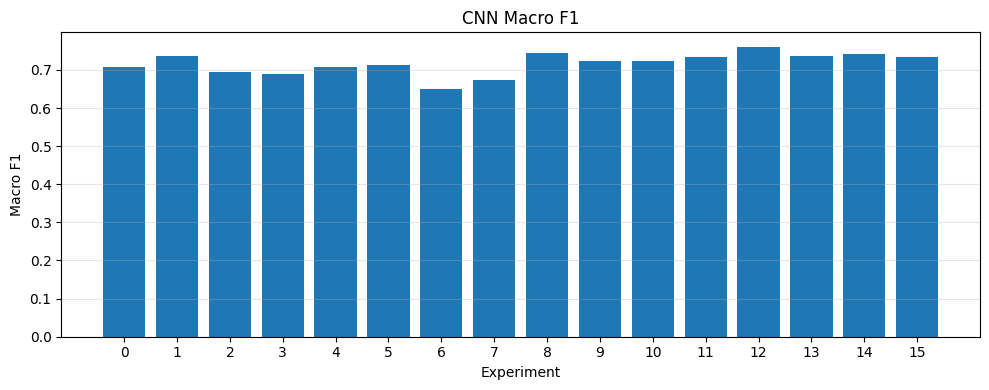

In [94]:
plot_df = cnn.sort_values('experiment')
plt.figure(figsize=(10, 4))
plt.bar(plot_df['experiment'].astype(str), plot_df['macro_f1'])
plt.xlabel('Experiment')
plt.ylabel('Macro F1')
plt.title('CNN Macro F1')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'cnn_macro_f1.png', dpi=150)
plt.show()


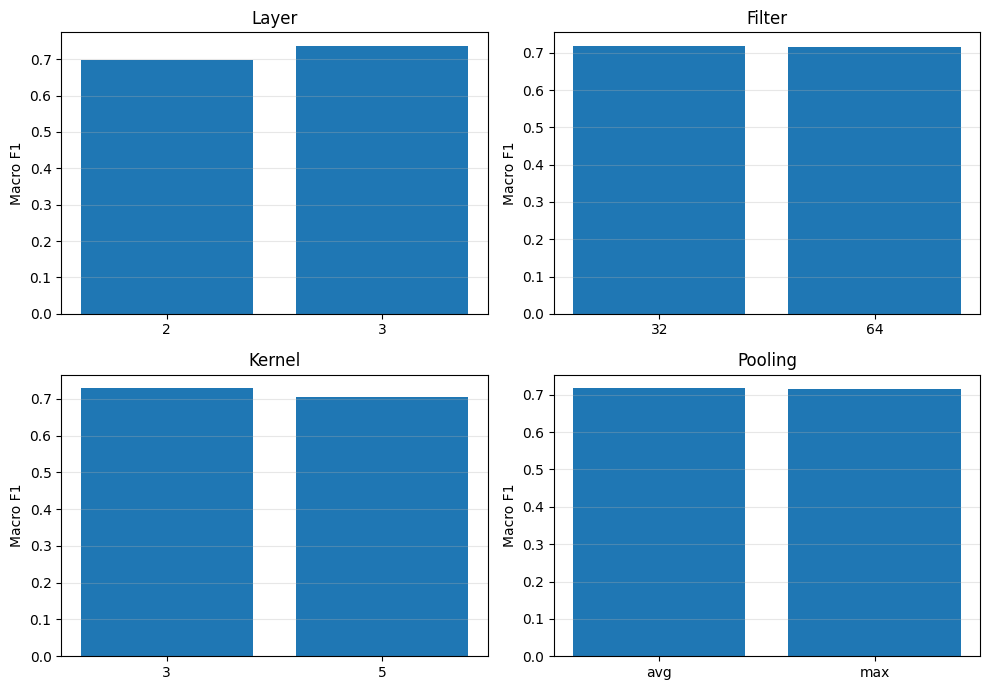

In [95]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, col, title in [
    (axes[0, 0], 'num_layers', 'Layer'),
    (axes[0, 1], 'filters', 'Filter'),
    (axes[1, 0], 'kernel_size', 'Kernel'),
    (axes[1, 1], 'pooling', 'Pooling'),
]:
    part = cnn.groupby(col)['macro_f1'].mean().reset_index()
    ax.bar(part[col].astype(str), part['macro_f1'])
    ax.set_title(title)
    ax.set_ylabel('Macro F1')
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'cnn_hyperparameter_effects.png', dpi=150)
plt.show()


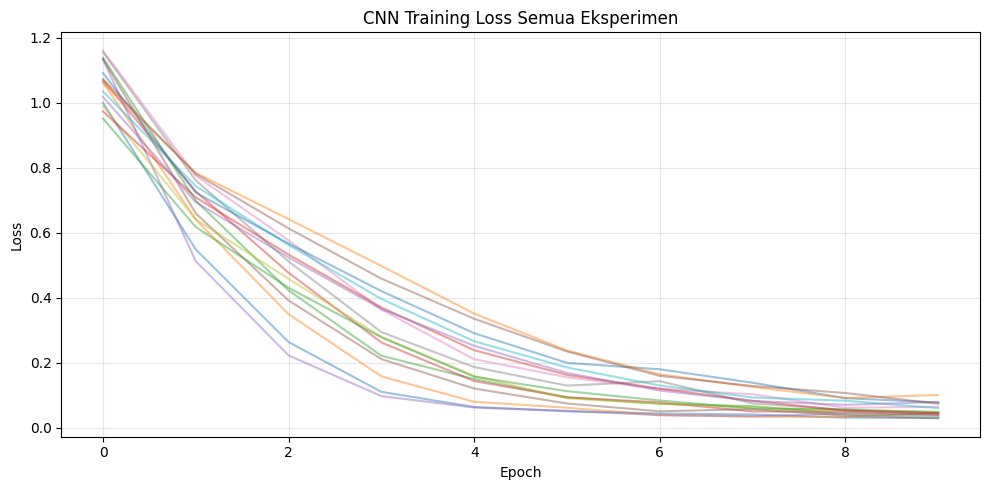

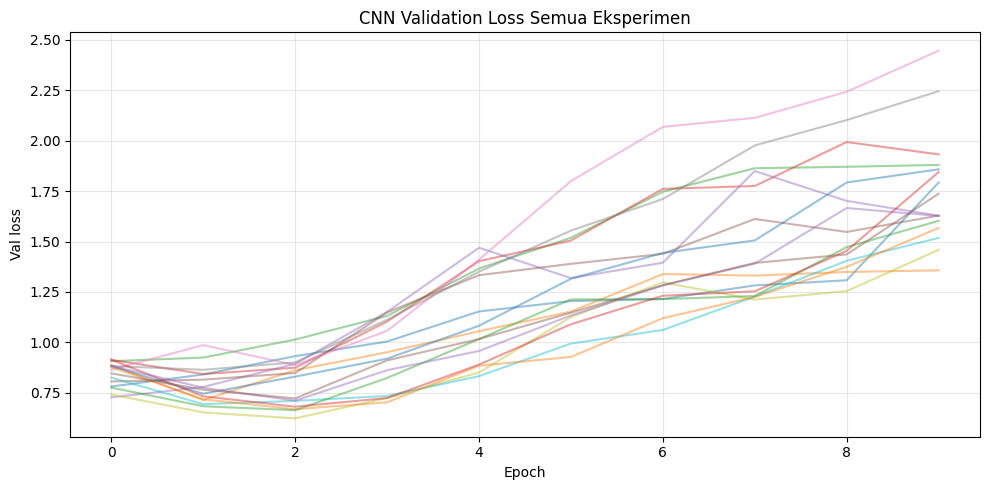

In [96]:
plt.figure(figsize=(10, 5))
for exp_id in sorted(cnn['experiment'].astype(int).unique()):
    path = CNN_MODEL_DIR / f'history_exp_{exp_id}.pkl'
    if not path.exists():
        continue
    with open(path, 'rb') as file:
        history = pickle.load(file)
    values = history.get('loss', [])
    if values:
        plt.plot(values, alpha=0.45, label=f'exp {exp_id}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Training Loss Semua Eksperimen')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'cnn_training_loss.png', dpi=150)
plt.show()

plt.figure(figsize=(10, 5))
for exp_id in sorted(cnn['experiment'].astype(int).unique()):
    path = CNN_MODEL_DIR / f'history_exp_{exp_id}.pkl'
    if not path.exists():
        continue
    with open(path, 'rb') as file:
        history = pickle.load(file)
    values = history.get('val_loss', [])
    if values:
        plt.plot(values, alpha=0.45, label=f'exp {exp_id}')
plt.xlabel('Epoch')
plt.ylabel('Val loss')
plt.title('CNN Validation Loss Semua Eksperimen')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'cnn_validation_loss.png', dpi=150)
plt.show()


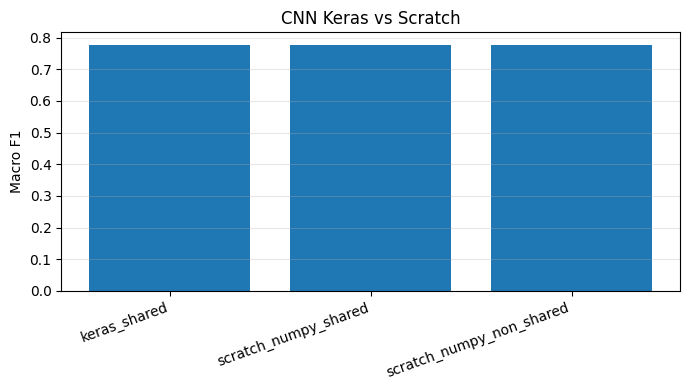

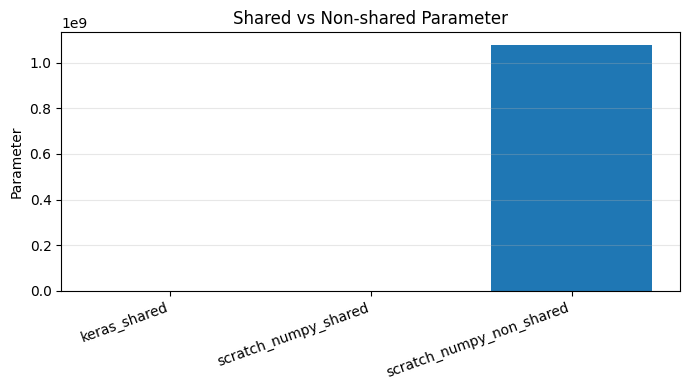

In [97]:
plt.figure(figsize=(7, 4))
labels = manual['implementation'].astype(str)
values = manual['macro_f1'].fillna(manual.get('macro_f1_small_batch', np.nan))
plt.bar(labels, values)
plt.xticks(rotation=20, ha='right')
plt.ylabel('Macro F1')
plt.title('CNN Keras vs Scratch')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'cnn_keras_vs_scratch.png', dpi=150)
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(labels, manual['params'])
plt.xticks(rotation=20, ha='right')
plt.ylabel('Parameter')
plt.title('Shared vs Non-shared Parameter')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'cnn_parameter_count.png', dpi=150)
plt.show()


---

# 06 RnnVisual


# 6. RnnVisual

Visualisasi hasil RNN/LSTM dari artefak yang sudah tersimpan.


In [98]:
from pathlib import Path
import sys

def find_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start] + list(start.parents):
        if (path / 'src').exists() and (path / 'data').exists():
            return path
    raise RuntimeError('root repo tidak ditemukan')

ROOT = find_root()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
print('root:', ROOT)


root: /Users/rusmn/Kuliah/SEMESTER 6/Machine Learning/Tubes2/ML-Tubes-2_RecursiveLearnaholic


In [99]:
import json
import pandas as pd
import matplotlib.pyplot as plt

TABLE_DIR = ROOT / 'reports/tables/rnn'
FIG_DIR = ROOT / 'reports/figures/rnn'
FIG_DIR.mkdir(parents=True, exist_ok=True)

scores = pd.read_csv(TABLE_DIR / 'rnn_lstm_results.csv')
comparison = pd.read_csv(TABLE_DIR / 'keras_vs_scratch.csv')
lengths = pd.read_csv(TABLE_DIR / 'length_scores.csv')
qualitative = pd.read_csv(TABLE_DIR / 'qualitative_examples.csv')
train_records = json.loads((TABLE_DIR / 'train_records.json').read_text(encoding='utf-8'))
expected = {Path(row['model_path']).name for row in train_records}
actual = {Path(row).name for row in scores['model_path'].astype(str)}
missing = sorted(expected - actual)
print('rnn:', len(scores), '/', len(expected), 'compare:', len(comparison), 'length:', len(lengths), 'contoh:', len(qualitative))
if missing:
    print('belum ada skor:', ', '.join(missing))


rnn: 12 / 12 compare: 4 length: 3 contoh: 10


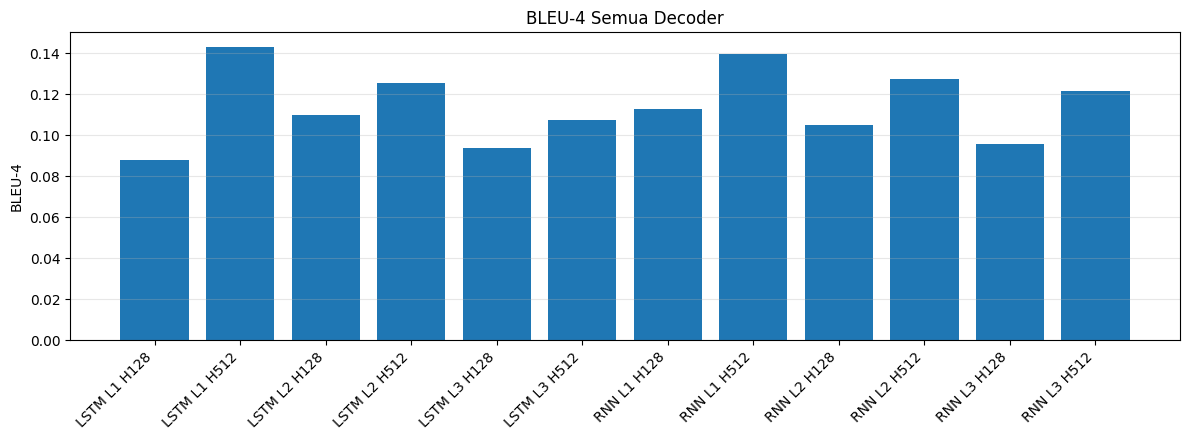

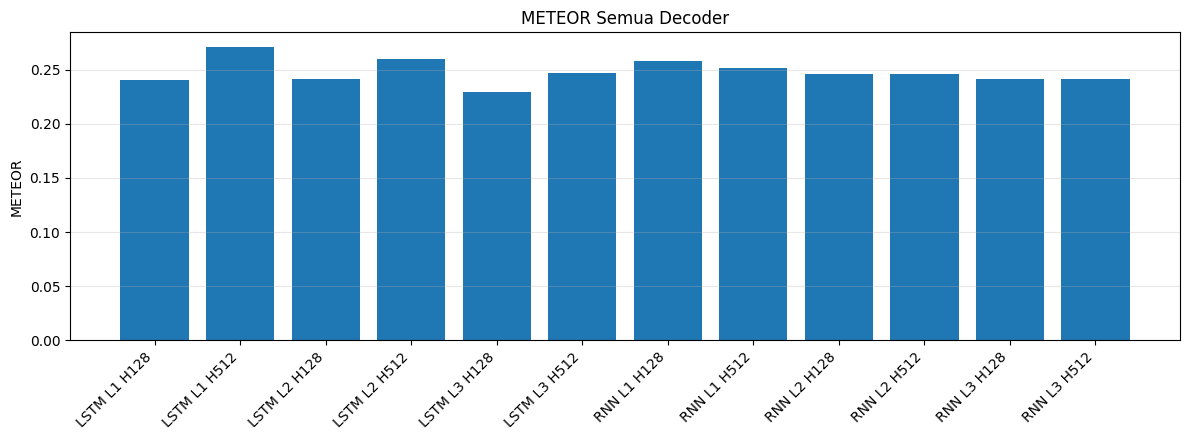

In [100]:
plot_scores = scores.copy().sort_values(['recur_type', 'recur_layers', 'hidden_size'])
plot_scores['label'] = plot_scores.apply(lambda row: f"{row['recur_type'].upper()} L{int(row['recur_layers'])} H{int(row['hidden_size'])}", axis=1)

plt.figure(figsize=(12, 4.5))
plt.bar(plot_scores['label'], plot_scores['bleu4'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('BLEU-4')
plt.title('BLEU-4 Semua Decoder')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'rnn_lstm_bleu4_variations.png', dpi=150)
plt.show()

plt.figure(figsize=(12, 4.5))
plt.bar(plot_scores['label'], plot_scores['meteor'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('METEOR')
plt.title('METEOR Semua Decoder')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'rnn_lstm_meteor_variations.png', dpi=150)
plt.show()


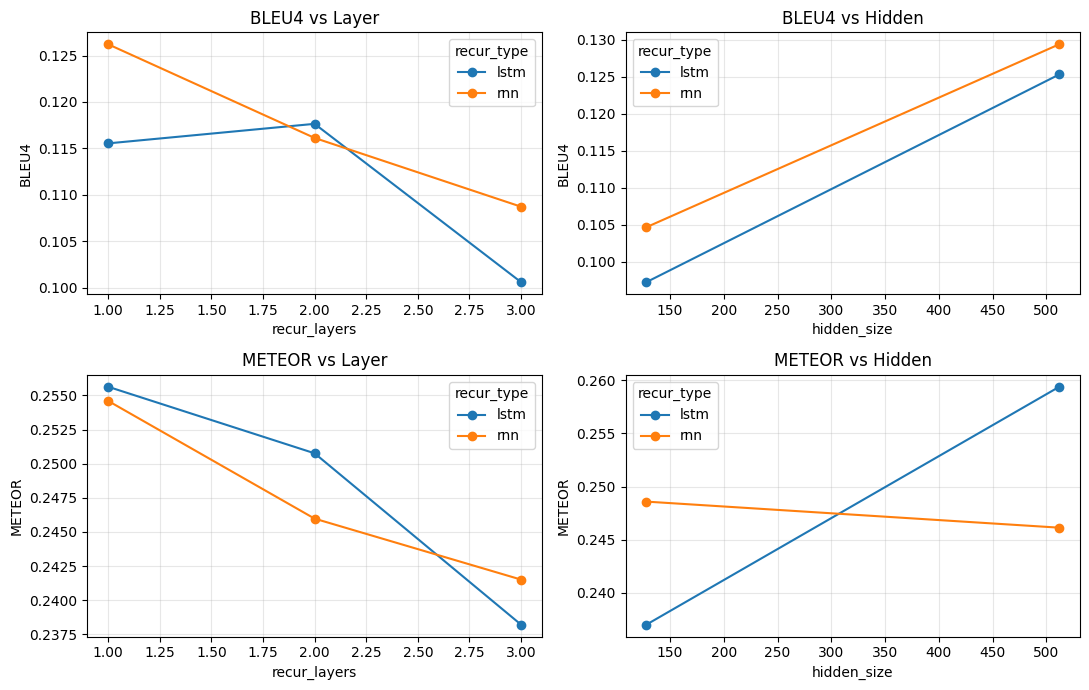

In [101]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for metric, row_axes in [('bleu4', axes[0]), ('meteor', axes[1])]:
    scores.groupby(['recur_type', 'recur_layers'])[metric].mean().unstack(0).plot(marker='o', ax=row_axes[0])
    row_axes[0].set_title(f'{metric.upper()} vs Layer')
    row_axes[0].set_ylabel(metric.upper())
    row_axes[0].grid(alpha=0.3)
    scores.groupby(['recur_type', 'hidden_size'])[metric].mean().unstack(0).plot(marker='o', ax=row_axes[1])
    row_axes[1].set_title(f'{metric.upper()} vs Hidden')
    row_axes[1].set_ylabel(metric.upper())
    row_axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'rnn_layer_hidden_effects.png', dpi=150)
plt.show()


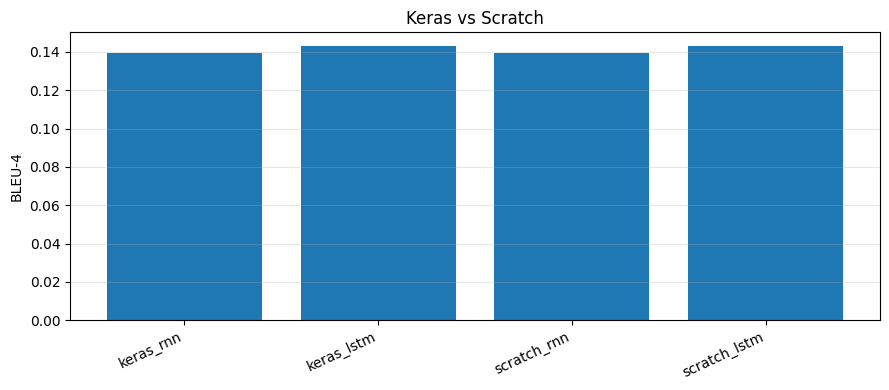

In [102]:
plt.figure(figsize=(9, 4))
labels = comparison['implementation'].astype(str) + '_' + comparison['recur_type'].astype(str)
plt.bar(labels, comparison['bleu4'])
plt.xticks(rotation=25, ha='right')
plt.ylabel('BLEU-4')
plt.title('Keras vs Scratch')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'rnn_keras_vs_scratch.png', dpi=150)
plt.show()


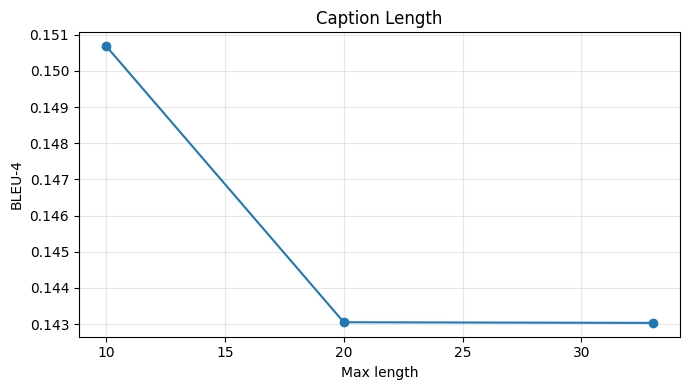

In [103]:
plt.figure(figsize=(7, 4))
plt.plot(lengths['max_length'], lengths['bleu4'], marker='o')
plt.xlabel('Max length')
plt.ylabel('BLEU-4')
plt.title('Caption Length')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'length_bleu4.png', dpi=150)
plt.show()


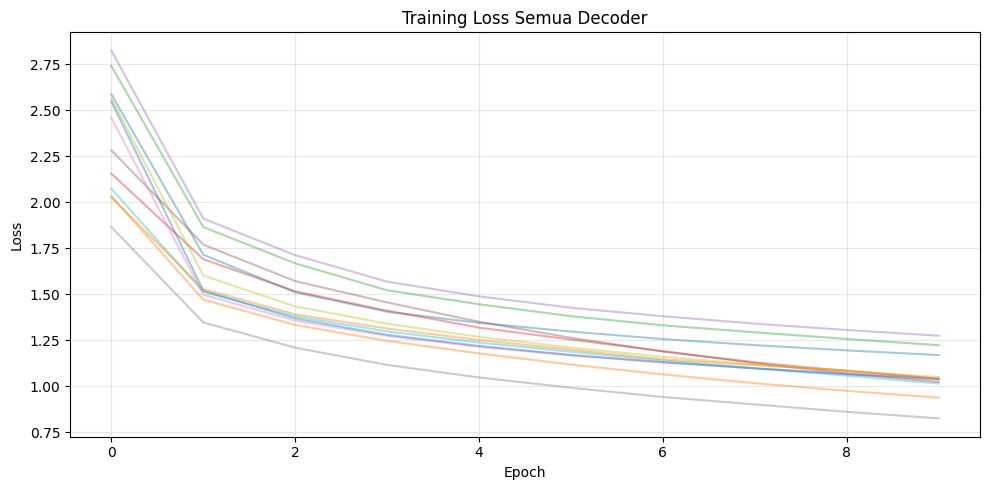

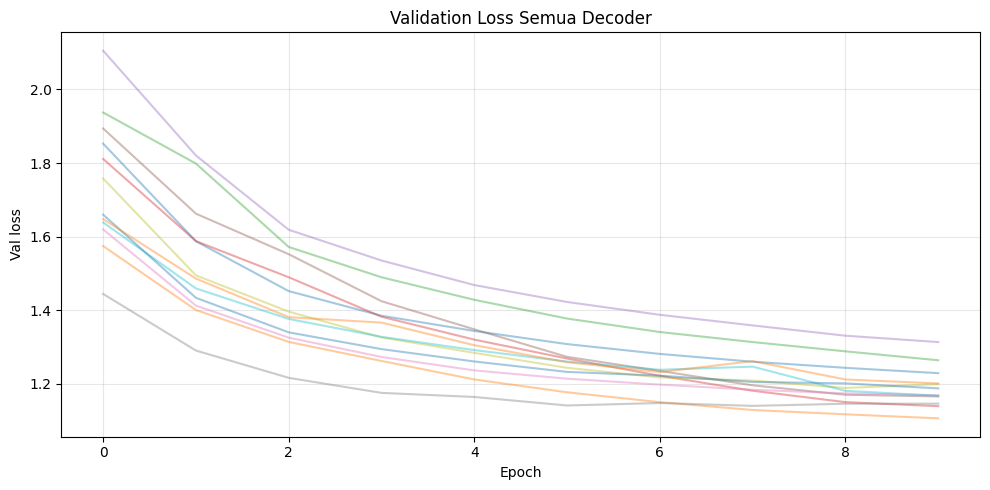

In [104]:
plt.figure(figsize=(10, 5))
for hist_path in sorted(TABLE_DIR.glob('*_history.json')):
    history = json.loads(hist_path.read_text(encoding='utf-8'))
    label = hist_path.stem.replace('_history', '')
    values = history.get('loss', [])
    if values:
        plt.plot(values, alpha=0.4, label=label)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Semua Decoder')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'training_loss_curves.png', dpi=150)
plt.show()

plt.figure(figsize=(10, 5))
for hist_path in sorted(TABLE_DIR.glob('*_history.json')):
    history = json.loads(hist_path.read_text(encoding='utf-8'))
    label = hist_path.stem.replace('_history', '')
    values = history.get('val_loss', [])
    if values:
        plt.plot(values, alpha=0.4, label=label)
plt.xlabel('Epoch')
plt.ylabel('Val loss')
plt.title('Validation Loss Semua Decoder')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'validation_loss_curves.png', dpi=150)
plt.show()


In [105]:
qualitative.head(10)


,image_id,avg_bleu4,ground_truth,rnn_prediction,lstm_prediction
0,3042380610_c5ea61eef8.jpg,0.015249,['a group of people are standing around a soun...,a man in a black shirt and a woman in a black ...,a man and a woman are sitting on a bench with ...
1,1235580648_7eebaed9bc.jpg,0.016235,"['the <unk> males pose for a picture', 'the tw...",a man in a black shirt and a woman in a black ...,a man in a blue shirt and a white shirt with a...
2,799431781_65dc312afc.jpg,0.017493,['the little boy covering his mouth is sitting...,a young girl in a blue shirt is standing in fr...,a woman in a white shirt is holding a baby in ...
3,440184957_267f3f3a2b.jpg,0.017540,"['a clown <unk> cutout pictures of children', ...",a girl in a blue shirt is standing in front of...,a woman in a white dress is standing in front ...
4,2098174172_e57d86ea03.jpg,0.064565,['a hiker is posing in front of snowy mountain...,a man is standing on a hill by a lake,a man in a red jacket is standing on a snowy m...
5,3310067561_b92017acab.jpg,0.065101,['a brown dog is sitting on a cobbled pavement...,a dog chews on a bone,a dog is running through a field of a man in a...
6,3187395715_f2940c2b72.jpg,0.065238,['a boy on skateboard is making a jump from a ...,a girl is jumping on a trampoline,a young boy wearing a blue shirt is jumping of...
7,2379150102_157d718d1d.jpg,0.065254,['a dog <unk> on the side of a fountain anothe...,a small dog is running on a grassy field,a dog is running through a field of a fence
8,327415627_6313d32a64.jpg,0.136444,['two dogs run along the green grass near the ...,two dogs are running through a field,a dog runs through the grass
9,2325258180_6217dd17eb.jpg,0.136488,['a black and brown dog is laying with a tiger...,a black dog is running on a grassy field,a black and white dog is running through a gra...
